##Comenzando


In [2]:
!pip install -q ultralytics gtts torchmetrics pycocotools openai-whisper jiwer
!apt-get install -y espeak-ng festival festvox-ellpc11k

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 510.3 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 3.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 42.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 35.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.0/248.0 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.1/91.1 kB 7.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following d

In [3]:
#@title Importamos las librerías necesarias
import os
import math
import time
import random
import statistics
from collections import defaultdict

import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import torch

from ultralytics import YOLO
# from ultralytics import RTDETR   # descomenta si tu versión lo soporta

from torchvision.ops import nms
from gtts import gTTS
from IPython.display import Audio, clear_output

# Colab específicos
from google.colab import drive
from google.colab.patches import cv2_imshow

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


In [4]:
print("PyTorch:   ", torch.__version__)
print("CUDA:      ", torch.cuda.is_available())
print("OpenCV:    ", cv2.__version__)

import ultralytics
print("Ultralytics:", ultralytics.__version__)

PyTorch:    2.11.0+cpu
CUDA:       False
OpenCV:     4.14.0
Ultralytics: 8.4.166


In [5]:
#@title Configurando el Drive.
# Setting up Drive.
drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive')
print(os.getcwd())

Mounted at /content/drive
/content/drive/MyDrive


In [6]:
"""
from gtts import gTTS
from IPython.display import Audio

#@title Definimos el modulo de Text-to-Speech
def play_text(input_text, lan="en"):
    file_name = "gtts_output.wav"
    tts = gTTS(input_text, lang=lan)
    tts.save(file_name)
    sound_file = file_name
    return Audio(sound_file, autoplay=True)
"""

'\nfrom gtts import gTTS\nfrom IPython.display import Audio\n\n#@title Definimos el modulo de Text-to-Speech\ndef play_text(input_text, lan="en"):\n    file_name = "gtts_output.wav"\n    tts = gTTS(input_text, lang=lan)\n    tts.save(file_name)\n    sound_file = file_name\n    return Audio(sound_file, autoplay=True)\n'

## Utilizamos una YOLO (You Only Look Once)

In [11]:
#Nos posicionamos en el directorio en donde está el Dataset.
#Position on the dataset's folder.
os.chdir('/content/drive/MyDrive/Trabajo de Grado/Dataset - Yolo')
print(os.getcwd())

/content/drive/MyDrive/Trabajo de Grado/Dataset - Yolo


In [12]:
model = YOLO('runs/detect/trainv8/weights/best.pt')
# Mostrar la información del modelo.
# Show the model information.
model.info()

Model summary: 130 layers, 11,156,498 parameters, 0 gradients, 28.8 GFLOPs


(130, 11156498, 0, 28.7560192)

In [13]:
#@title cajas y nms
#Metodo para obtener las annotaciones en un mismo formato.
#Method to obtain all annotations in the same format.
def parse_annotation(annotation_text):
    labels = []

    for line in annotation_text.strip().split("\n"):
          polygon = []
          values = line.split()

          for n in values:
            polygon.append(float(n))
          labels.append(polygon)

    return labels

#Metodo para dibujar poligonos/bounding boxes en la imagen.
#Method to draw the polygons/bounding boxes in the image.
def draw_polygons(image, labels, color=(86,5,145)):
    img = image.copy()

    h, w = img.shape[:2]
    for n in labels:
      if len(n) == 5:
        id_class = int(n[0])
        x1 = int((n[1] - n[3]/2) * w)
        y1 = int((n[2] - n[4]/2) * h)

        x2 = int((n[1] + n[3]/2) * w)
        y2 = int((n[2] + n[4]/2) * h)

        cv2.rectangle(img,(x1, y1),(x2, y2),color,2)

        cv2.putText(img, str(id_class), (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)

      else:
        id_class = int(n[0])
        coords = np.array(n[1:], dtype=np.float32)

        coords[0::2] *= w  # x
        coords[1::2] *= h  # y

        pts = coords.reshape(-1, 2).astype(np.int32)

        cv2.polylines(img, [pts], isClosed=True, color=color, thickness=2)
        cv2.putText(img, str(id_class), (pts[0,0], pts[0,1]-5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)

    return img

def nms_Yolo(results, image, iou=0.3):
    # Obtenemos las cajas, los puntajes y las clases.
    # Get the boxes, scores and classes.
    boxes = results[0].boxes.xyxy
    scores = results[0].boxes.conf
    classes = results[0].boxes.cls

    # Aplicar NMS manualmente con IoU
    # Apply NMS manually with IoU
    keep = nms(boxes, scores, iou_threshold=iou)

    # Filtrar resultados
    # Filter the results
    filtered_boxes = boxes[keep]
    filtered_scores = scores[keep]
    filtered_classes = classes[keep]

    image = results[0].orig_img.copy()

    # Usa las predicciones filtradas con NMS
    # Use filtered predictions with NMS
    for i in range(len(keep)):
        cls = int(filtered_classes[i])
        conf = float(filtered_scores[i])
        x1, y1, x2, y2 = map(int, filtered_boxes[i])
        label = f"{results[0].names[cls]}"

        # Dibujar rectángulo
        # Draw the rectangle
        cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 255), 2)

        # Etiqueta con fondo
        # Label with background
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 1)
        cv2.rectangle(image, (x1, y1 - th - 4), (x1 + tw, y1), (0, 255, 255), -1)
        cv2.putText(image, label, (x1, y1 - 4), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 1)

    text = spatial_organization(results, keep, filtered_boxes, filtered_classes)

    return image, text

def spatial_organization(results, keep, filtered_boxes, filtered_classes):
    # Declaramos un diccionario para caracteres especiales
    special_characters = {
        'a_tilde': 'á', 'ampersand': '&', 'apostrophe': "'", 'asterisk': '*', 'close_parenthesis': ')', 'closequotation': '"', 'colon': ':', 'comma': ',', 'e_tilde': 'é', 'exclamation_mark': '!', 'greaterthan': '>', 'hyphen': '-', 'i_tilde': 'í', 'lessthan': '<', 'minus': '-', 'n_tilde': 'ñ', 'o_tilde': 'ó', 'open_parenthesis': '(', 'parentheses': '()', 'period': '.', 'question_mark': '?', 'semicolon': ';', 'slash': '/', 'u_dieresis': 'ü', 'u_tilde': 'ú'
    }
    numbers = {
        'j': '0', 'a': '1', 'b': '2', 'c': '3', 'd': '4', 'e': '5', 'f': '6', 'g': '7', 'h': '8', 'i': '9'
    }
    #Instanciamos una lista para guardar la altura de las bounding boxes
    y_difference = []
    # Agrupar por líneas (por y1)
    line_groups = defaultdict(list)
    #Revisamos que hayan bounding boxes que organizar
    lenght = len(filtered_boxes)
    if lenght == 0:
      return []
    else:
      for n in range(len(keep)):
        y_difference.append(np.abs(filtered_boxes[n][1].item()-filtered_boxes[n][3].item()))

    #Sacamos un promedio de las alturas de todas las letras
    y_threshold = statistics.mean(y_difference)
    y_threshold = y_threshold * 0.9 # tolerancia vertical en píxeles

    #Ordenamos las cajas respecto a sus posiciones en X (De izquierda a derecha)
    ordered_boxes = sorted(zip(filtered_boxes,filtered_classes), key= lambda x: x[0][0])
    filtered_boxes = [x for x,y in ordered_boxes]
    filtered_classes = [y for x,y in ordered_boxes]

    # Agrupar letras por líneas
    for i in range(len(keep)):
        #Extraer los datos de todas las detecciones, clase como string, bounding box y la posición en Y centrada
        cls = int(filtered_classes[i])
        letra = results[0].names[cls].lower()
        x1, y1, x2, y2 = filtered_boxes[i].tolist()
        y_center = (y1 + y2) / 2

        # Asignar a una línea existente o crear una nueva
        added = False

        #Iteramos por todas las bounding boxes mirando cuales están dentro de la tolerancia vertical de la primera, así separaos las lineas
        for key in line_groups:
            if abs(key - y_center) < y_threshold:
                line_groups[key].append((x1, letra))
                added = True
                break
        if not added:
            line_groups[y_center].append((x1, letra))

    # Ordenamos las líneas verticalmente (de arriba hacia abajo)
    sorted_lines = sorted(line_groups.items(), key=lambda x: x[0])

    # Instanciamos lista para el texto final
    texto_final = []
    for _, letras in sorted_lines:
        letras.sort(key=lambda x: x[0])  # ordenar letras por x

        #Aplicar transforamciones a caracteres especiales
        for n in range(len(letras)):
            if letras[n][1] in special_characters:
                letras[n] = (letras[n][0], special_characters[letras[n][1]])
            if letras[n][1] == 'capital':
                letras[n] = (letras[n][0], '')
                if n+1 < len(letras):
                  letras[n+1] = (letras[n+1][0], letras[n+1][1].upper())
            if letras[n][1] == 'number_sign':
                letras[n] = (letras[n][0], '')
                if n+1 < len(letras):
                  if letras[n+1][1] in numbers:
                    letras[n+1] = (letras[n+1][0], numbers[letras[n+1][1]])
            if letras[n][1] == 'letter_sign':
                letras[n] = (letras[n][0], '')

        # Calcular distancia promedio entre letras
        # Se extraen las coordenadas en x
        x_coords = [x for x, _ in letras]
        # Se calculan las distancias
        dists = [x_coords[i+1] - x_coords[i] for i in range(len(x_coords)-1)]
        if len(dists) > 0:
            avg_dist = sum(dists) / len(dists)
        else:
            avg_dist = 0
        space_threshold = avg_dist * 1.2  # Tolerancia horizontal + 20% de error

        # Construir línea con espacios
        linea = letras[0][1]
        for i in range(1, len(letras)):
            # Se calcula la distancia
            gap = letras[i][0] - letras[i-1][0]
            if gap > space_threshold: #Si la distancia es mayor al umbral, se pone un espacio
                linea += ' '  # espacio entre palabras
            linea += letras[i][1]

        texto_final.append(linea)

    return texto_final

def play_text(input_text, lan="en", output_filename="temp_audio.mp3", autoplay=True): # Modified to accept filename and autoplay
    if not input_text:
        return None
    else:
        tts = gTTS(input_text, lang=lan)
        tts.save(output_filename)
    if autoplay:
        return Audio(output_filename, autoplay=True)
    return output_filename # Return the filename if not autoplaying

/content/drive/MyDrive/Trabajo de Grado/Dataset - Yolo

image 1/1 /content/drive/MyDrive/Trabajo de Grado/Dataset - Yolo/test/images/BRA465_jpg.rf.bb961746a4d3967bd3171e138ceb7629.jpg: 640x640 1 A, 1 B, 1 C, 1 D, 2 Is, 2 Ms, 1 N, 2 Os, 1 T, 1 U, 1 i_tilde, 933.6ms
Speed: 12.9ms preprocess, 933.6ms inference, 2.4ms postprocess per image at shape (1, 3, 640, 640)
Clase: O, Confianza: 0.92, Coordenadas: [551.6618041992188, 183.89126586914062, 601.7794799804688, 239.13174438476562]
Clase: I, Confianza: 0.90, Coordenadas: [237.02597045898438, 184.101806640625, 280.6758117675781, 242.56329345703125]
Clase: T, Confianza: 0.88, Coordenadas: [399.90087890625, 179.13722229003906, 450.0421142578125, 242.21275329589844]
Clase: N, Confianza: 0.88, Coordenadas: [229.36248779296875, 289.1282958984375, 278.49945068359375, 345.46533203125]
Clase: i_tilde, Confianza: 0.88, Coordenadas: [358.9432373046875, 294.4817810058594, 405.7532958984375, 345.0151672363281]
Clase: I, Confianza: 0.88, Coordenadas: [1

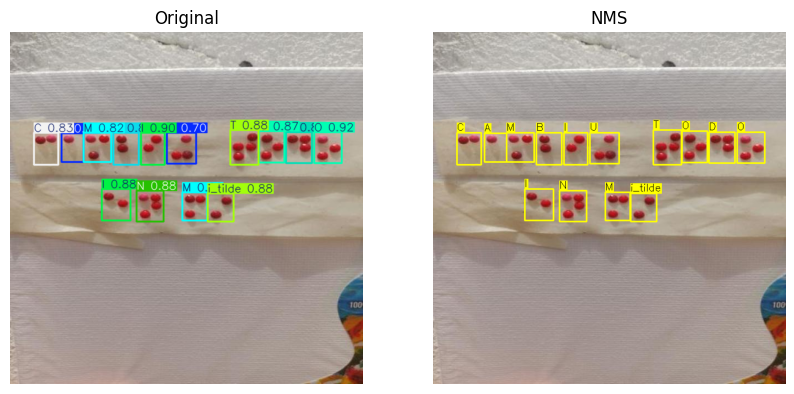

---------------------
cambiu todo
in mí
---------------------
['cambiu todo', 'in mí']
---------------------


In [14]:
#@title Carga tu modelo entrenado.
# Load the trained model.
yolo_trained = YOLO('runs/detect/trainv8/weights/best.pt')

# Haz una predicción sobre una imagen.
# Make a prediction on an image.
print(os.getcwd())
results = yolo_trained.predict(source='/content/drive/MyDrive/Trabajo de Grado/Dataset - Yolo/test/images/BRA465_jpg.rf.bb961746a4d3967bd3171e138ceb7629.jpg', save=False, conf=0.5)

# Mostrar resultados en texto.
# Show results on text.
for box in results[0].boxes:
    cls = int(box.cls[0])
    conf = float(box.conf[0])
    coords = box.xyxy[0].tolist()
    print(f"Clase: {results[0].names[cls]}, Confianza: {conf:.2f}, Coordenadas: {coords}")

# Mostrar la imagen
nms_results, text_results = nms_Yolo(results, results[0].orig_img, iou=0.3)
nms_results = cv2.cvtColor(nms_results, cv2.COLOR_BGR2RGB)
og_results = cv2.cvtColor(results[0].plot(), cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 10))
plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(og_results)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("NMS")
plt.imshow(nms_results)
plt.axis('off')

plt.show()

print("---------------------")
for line in text_results:
    print(line)
print("---------------------")
print(text_results)
print("---------------------")



##TTS Y PRUEBAS

In [ ]:
#@title prueba WER con YOLO
from IPython.display import Audio, display
import pandas as pd
from ultralytics import YOLO
import cv2
import whisper
from jiwer import wer
import time
from gtts import gTTS
import os
import re

# ==================== 0. TEXTO CORRECTO (GROUND TRUTH) ====================
print("="*60)
print(" PASO 0: Definir el texto CORRECTO (Ground Truth)")
print("="*60)

# TEXTO CORRECTO
texto_ground_truth = "cambio todo en mí"  # ← SE CAMBIA ESTO

print(f" Texto correcto (Ground Truth): '{texto_ground_truth}'")
print("="*60)

# ==================== 1. DETECCIÓN CON YOLO (OBLIGATORIO) ====================
print("\n PASO 1: Detectando texto con YOLO")
print("="*60)

# Cargar modelo entrenado
yolo_trained = YOLO('runs/detect/trainv8/weights/best.pt')

# Ruta de la imagen
imagen_path = '/content/drive/MyDrive/Trabajo de Grado/Dataset - Yolo/test/images/BRA465_jpg.rf.bb961746a4d3967bd3171e138ceb7629.jpg'

# Predecir
results = yolo_trained.predict(
    source=imagen_path,
    save=False,
    conf=0.5
)

# Obtener texto con NMS y organización espacial
nms_results, text_results = nms_Yolo(results, results[0].orig_img, iou=0.3)
texto_detectado_yolo = " ".join(text_results)

print(f" Texto detectado por YOLO: '{texto_detectado_yolo}'")
print("="*60)

# ==================== 2. GENERAR AUDIO CON TTS (USANDO YOLO) ====================
print("\n PASO 2: Generando audio con TTS (gTTS) usando lo que detectó YOLO")
print("="*60)

def generate_tts_audio(text, lang='es', output_file="tts_output.wav"):
    try:
        tts = gTTS(text=text, lang=lang, slow=False)
        tts.save(output_file)
        print(f" Audio generado: {output_file}")
        print(f"   Texto leído (desde YOLO): '{text}'")
        return output_file
    except Exception as e:
        print(f" Error en gTTS: {e}")
        return None

#  EL AUDIO SE GENERA CON LO QUE DETECTÓ YOLO
audio_file = generate_tts_audio(texto_detectado_yolo, lang='es', output_file="gtts_output.wav")

if not audio_file:
    print(" No se pudo generar el audio. Deteniendo...")
    exit()

# ==================== 3. REPRODUCIR AUDIO ====================
print("\n PASO 3: Reproduciendo audio")
print("="*60)

display(Audio(audio_file, autoplay=True))

# ==================== 4. TRANSCRIBIR CON WHISPER ====================
print("\n PASO 4: Transcribiendo audio con Whisper")
print("="*60)

def transcribe_with_whisper(audio_file, model_size="small", language="es"):
    try:
        print(f"   Cargando modelo Whisper '{model_size}'...")
        model = whisper.load_model(model_size)

        print(f"   Transcribiendo {audio_file}...")
        start_time = time.time()
        result = model.transcribe(audio_file, language=language, fp16=False)
        elapsed_time = time.time() - start_time

        transcripcion = result["text"].strip()
        print(f" Transcripción: '{transcripcion}'")

        return transcripcion, elapsed_time
    except Exception as e:
        print(f" Error en Whisper: {e}")
        return None, None

transcripcion_whisper, tiempo_asr = transcribe_with_whisper(audio_file, model_size="small", language="es")

if not transcripcion_whisper:
    print("No se pudo transcribir el audio. Deteniendo...")
    exit()

# ==================== 5. LIMPIAR TEXTO (IGNORA MAYÚSCULAS Y PUNTUACIÓN) ====================
def limpiar_texto_para_wer(texto):
    """
    Limpia el texto para calcular WER:
    - Convierte a minúsculas
    - Elimina puntos finales, comas y otros signos de puntuación
    - Elimina espacios extra
    """
    texto = texto.lower().strip()
    texto = re.sub(r'[.,!?;:()"\'-]', '', texto)
    texto = re.sub(r'\s+', ' ', texto)
    return texto.strip()

# ==================== 6. CALCULAR WER (GROUND TRUTH vs TRANSCRIPCIÓN) ====================
print("\n PASO 5: Calculando WER (Ground Truth vs Transcripción)")
print("="*60)

def calculate_wer_limpio(reference_text, hypothesis_text):
    """
    Calcula WER entre ground truth y transcripción
    """
    try:
        # Limpiar ambos textos
        ref_clean = limpiar_texto_para_wer(reference_text)
        hyp_clean = limpiar_texto_para_wer(hypothesis_text)

        print(f"   Ground Truth limpio: '{ref_clean}'")
        print(f"   Transcripción limpia: '{hyp_clean}'")

        # Calcular WER
        wer_score = wer(ref_clean, hyp_clean)

        # Estadísticas adicionales
        ref_words = ref_clean.split()
        hyp_words = hyp_clean.split()

        from collections import Counter
        ref_counter = Counter(ref_words)
        hyp_counter = Counter(hyp_words)

        common = sum((ref_counter & hyp_counter).values())
        substitutions = len(ref_words) - common
        insertions = len(hyp_words) - common
        deletions = len(ref_words) - len(hyp_words)

        if deletions < 0:
            insertions = abs(deletions)
            deletions = 0

        measures = {
            'substitutions': max(0, substitutions),
            'insertions': max(0, insertions),
            'deletions': max(0, deletions),
            'reference_length': len(ref_words),
            'hypothesis_length': len(hyp_words)
        }

        return wer_score, measures
    except Exception as e:
        print(f" Error en WER: {e}")
        return 1.0, {}

#  COMPARAMOS GROUND TRUTH vs TRANSCRIPCIÓN (WHISPER)
wer_score, medidas = calculate_wer_limpio(texto_ground_truth, transcripcion_whisper)

# ==================== 7. MOSTRAR RESULTADOS ====================
print("\n" + "="*60)
print(" RESULTADOS FINALES")
print("="*60)

print(f"\n GROUND TRUTH:")
print(f"   Original: '{texto_ground_truth}'")
print(f"   Limpio: '{limpiar_texto_para_wer(texto_ground_truth)}'")

print(f"\n TEXTO DETECTADO POR YOLO:")
print(f"   '{texto_detectado_yolo}'")

print(f"\n TRANSCRIPCIÓN (Whisper - lo que escuchó):")
print(f"   Original: '{transcripcion_whisper}'")
print(f"   Limpio: '{limpiar_texto_para_wer(transcripcion_whisper)}'")

print(f"\n WER (Ground Truth vs Transcripción):")
print(f"   {wer_score*100:.2f}%")

if wer_score == 0:
    print("    ¡Perfecto! La transcripción coincide con el Ground Truth")
elif wer_score < 0.1:
    print("    Excelente (menos del 10% de error)")
elif wer_score < 0.2:
    print("    Bueno (10-20% de error)")
elif wer_score < 0.4:
    print("    Aceptable (20-40% de error)")
else:
    print("    Necesita mejorar (más del 40% de error)")

print(f"\n ESTADÍSTICAS DETALLADAS:")
print(f"   - Sustituciones: {medidas.get('substitutions', 0)}")
print(f"   - Inserciones: {medidas.get('insertions', 0)}")
print(f"   - Eliminaciones: {medidas.get('deletions', 0)}")
print(f"   - Total palabras Ground Truth: {medidas.get('reference_length', 0)}")
print(f"   - Total palabras Transcripción: {medidas.get('hypothesis_length', 0)}")
print(f"   - Tiempo ASR: {tiempo_asr:.2f}s")


# Mostrar comparación de textos
print("\n" + "="*60)
print(" COMPARACIÓN DIRECTA:")
print("="*60)
print(f"Ground Truth:    '{limpiar_texto_para_wer(texto_ground_truth)}'")
print(f"Transcripción:   '{limpiar_texto_para_wer(transcripcion_whisper)}'")
print(f"WER:             {wer_score*100:.2f}%")


 PASO 0: Definir el texto CORRECTO (Ground Truth)
 Texto correcto (Ground Truth): 'cambio todo en mí'

 PASO 1: Detectando texto con YOLO

image 1/1 /content/drive/MyDrive/Trabajo de Grado/Dataset - Yolo/test/images/BRA465_jpg.rf.bb961746a4d3967bd3171e138ceb7629.jpg: 640x640 1 A, 1 B, 1 C, 1 D, 2 Is, 2 Ms, 1 N, 2 Os, 1 T, 1 U, 1 i_tilde, 774.8ms
Speed: 11.8ms preprocess, 774.8ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)
 Texto detectado por YOLO: 'cambiu todo in mí'

 PASO 2: Generando audio con TTS (gTTS) usando lo que detectó YOLO
 Audio generado: gtts_output.wav
   Texto leído (desde YOLO): 'cambiu todo in mí'

 PASO 3: Reproduciendo audio



 PASO 4: Transcribiendo audio con Whisper
   Cargando modelo Whisper 'small'...


100%|████████████████████████████████████████| 461M/461M [00:02<00:00, 191MiB/s]


   Transcribiendo gtts_output.wav...
 Transcripción: 'Cambio todo en mí.'

 PASO 5: Calculando WER (Ground Truth vs Transcripción)
   Ground Truth limpio: 'cambio todo en mí'
   Transcripción limpia: 'cambio todo en mí'

 RESULTADOS FINALES

 GROUND TRUTH:
   Original: 'cambio todo en mí'
   Limpio: 'cambio todo en mí'

 TEXTO DETECTADO POR YOLO:
   'cambiu todo in mí'

 TRANSCRIPCIÓN (Whisper - lo que escuchó):
   Original: 'Cambio todo en mí.'
   Limpio: 'cambio todo en mí'

 WER (Ground Truth vs Transcripción):
   0.00%
    ¡Perfecto! La transcripción coincide con el Ground Truth

 ESTADÍSTICAS DETALLADAS:
   - Sustituciones: 0
   - Inserciones: 0
   - Eliminaciones: 0
   - Total palabras Ground Truth: 4
   - Total palabras Transcripción: 4
   - Tiempo ASR: 10.35s

 COMPARACIÓN DIRECTA:
Ground Truth:    'cambio todo en mí'
Transcripción:   'cambio todo en mí'
WER:             0.00%


In [ ]:
#@title analisis indv
import re
from difflib import SequenceMatcher

def alinear_palabras(ref_words, hyp_words):
    """
    Alinea dos listas de palabras usando LCS (Longest Common Subsequence)
    """
    # Crear matriz de coincidencias
    n, m = len(ref_words), len(hyp_words)
    dp = [[0] * (m + 1) for _ in range(n + 1)]

    # Llenar matriz para LCS
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            if ref_words[i-1] == hyp_words[j-1]:
                dp[i][j] = dp[i-1][j-1] + 1
            else:
                dp[i][j] = max(dp[i-1][j], dp[i][j-1])

    # Reconstruir alineación
    i, j = n, m
    alineacion = []

    while i > 0 or j > 0:
        if i > 0 and j > 0 and ref_words[i-1] == hyp_words[j-1]:
            alineacion.append(('equal', ref_words[i-1], hyp_words[j-1]))
            i -= 1
            j -= 1
        elif j > 0 and (i == 0 or dp[i][j-1] >= dp[i-1][j]):
            alineacion.append(('insertion', None, hyp_words[j-1]))
            j -= 1
        elif i > 0 and (j == 0 or dp[i-1][j] > dp[i][j-1]):
            alineacion.append(('deletion', ref_words[i-1], None))
            i -= 1
        else:
            break

    alineacion.reverse()
    return alineacion

# ==================== ANALIZAR ERRORES ====================
def analizar_errores_wer(reference, hypothesis):
    """
    Analiza y muestra los errores específicos del WER:
    - Sustituciones: palabras diferentes
    - Inserciones: palabras extra en la transcripción
    - Eliminaciones: palabras faltantes en la transcripción
    - Palabras correctas: coinciden exactamente
    """
    # Limpiar textos
    ref_clean = limpiar_texto_para_wer(reference)
    hyp_clean = limpiar_texto_para_wer(hypothesis)

    # Dividir en palabras
    ref_words = ref_clean.split()
    hyp_words = hyp_clean.split()

    # Alinear palabras
    alineacion = alinear_palabras(ref_words, hyp_words)

    # Clasificar errores
    sustituciones = []
    inserciones = []
    eliminaciones = []
    correctas = []

    for tipo, ref, hyp in alineacion:
        if tipo == 'equal':
            correctas.append(ref)
        elif tipo == 'substitution':
            sustituciones.append({
                'referencia': ref,
                'hipotesis': hyp
            })
        elif tipo == 'insertion':
            inserciones.append(hyp)
        elif tipo == 'deletion':
            eliminaciones.append(ref)

    return {
        'correctas': correctas,
        'sustituciones': sustituciones,
        'inserciones': inserciones,
        'eliminaciones': eliminaciones,
        'total_referencia': len(ref_words),
        'total_hipotesis': len(hyp_words)
    }

print("\n" + "="*60)
print(" ANÁLISIS DETALLADO DE ERRORES")
print("="*60)

# Usar las variables que ya tienes de tu celda anterior
try:
    # Analizar errores
    errores = analizar_errores_wer(texto_ground_truth, transcripcion_whisper)

    # Palabras correctas
    print(f"\n PALABRAS CORRECTAS ({len(errores['correctas'])}):")
    if errores['correctas']:
        print(f"   {', '.join(errores['correctas'])}")
    else:
        print("   (Ninguna)")

    # Sustituciones
    print(f"\n SUSTITUCIONES ({len(errores['sustituciones'])}):")
    if errores['sustituciones']:
        for s in errores['sustituciones']:
            print(f"    '{s['referencia']}' → '{s['hipotesis']}'")
    else:
        print("   Ninguna sustitución")

    # Inserciones
    print(f"\n INSERCIONES ({len(errores['inserciones'])}):")
    if errores['inserciones']:
        for i in errores['inserciones']:
            print(f"    '{i}' (extra en transcripción)")
    else:
        print("    Ninguna inserción")

    # Eliminaciones
    print(f"\n ELIMINACIONES ({len(errores['eliminaciones'])}):")
    if errores['eliminaciones']:
        for e in errores['eliminaciones']:
            print(f"    '{e}' (faltante en transcripción)")
    else:
        print("    Ninguna eliminación")

except NameError as e:
    print(f"\n Error: {e}")
    print("   Asegúrate de que las variables 'texto_ground_truth' y 'transcripcion_whisper' existan.")
    print("   Ejecuta primero la celda principal que las define.")
except Exception as e:
    print(f"\n Error inesperado: {e}")
    import traceback
    traceback.print_exc()

print("\n" + "="*60)


 ANÁLISIS DETALLADO DE ERRORES

 PALABRAS CORRECTAS (4):
   cambio, todo, en, mí

 SUSTITUCIONES (0):
   Ninguna sustitución

 INSERCIONES (0):
    Ninguna inserción

 ELIMINACIONES (0):
    Ninguna eliminación



## Utilizamos una RT-DETR

/content/drive/MyDrive/Trabajo de Grado/Dataset - Yolo

image 1/1 /content/drive/MyDrive/Trabajo de Grado/Dataset - Yolo/test/images/BRA465_jpg.rf.bb961746a4d3967bd3171e138ceb7629.jpg: 640x640 1 A, 1 B, 1 C, 1 D, 1 E, 2 Is, 2 Ms, 1 N, 2 Os, 1 S, 1 T, 1 U, 2475.9ms
Speed: 7.0ms preprocess, 2475.9ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)
Clase: N, Confianza: 0.91, Coordenadas: [229.06051635742188, 289.7514953613281, 277.46771240234375, 343.6988525390625]
Clase: T, Confianza: 0.91, Coordenadas: [402.3200988769531, 181.18411254882812, 450.24688720703125, 238.19313049316406]
Clase: M, Confianza: 0.90, Coordenadas: [133.18365478515625, 183.86886596679688, 183.5015869140625, 236.6029052734375]
Clase: O, Confianza: 0.90, Coordenadas: [553.4503173828125, 186.71426391601562, 600.5015869140625, 237.52801513671875]
Clase: M, Confianza: 0.89, Coordenadas: [312.48486328125, 293.5059509277344, 357.3596496582031, 342.7913818359375]
Clase: O, Confianza: 0.89, Coordenadas: [451

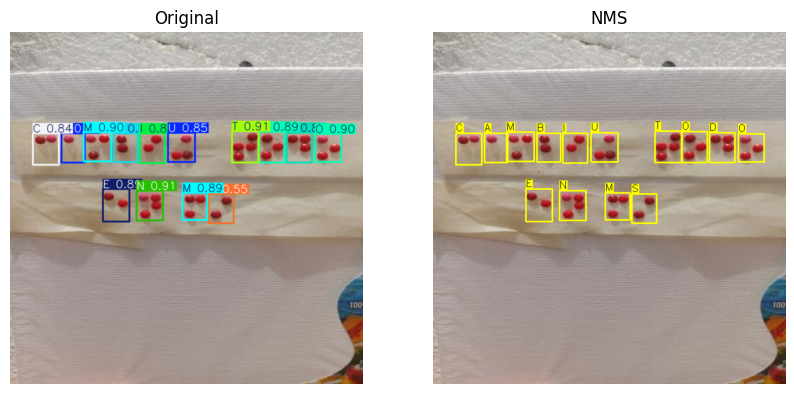

---------------------
cambiu todo
en ms
---------------------
['cambiu todo', 'en ms']
---------------------


In [15]:
#@title Carga tu modelo RT-DETR entrenado
from ultralytics import RTDETR   # ← cambio clave
import os, cv2, matplotlib.pyplot as plt

# Cargar el modelo RT-DETR entrenado
model_trans = RTDETR('/content/drive/MyDrive/Trabajo de Grado/runs/detect/train_trans/weights/best.pt')

# Predicción sobre una imagen
print(os.getcwd())
results = model_trans.predict(
    source='/content/drive/MyDrive/Trabajo de Grado/Dataset - Yolo/test/images/BRA465_jpg.rf.bb961746a4d3967bd3171e138ceb7629.jpg',
    save=False,
    conf=0.5
)

# Mostrar resultados en texto
for box in results[0].boxes:
    cls = int(box.cls[0])
    conf = float(box.conf[0])
    coords = box.xyxy[0].tolist()
    print(f"Clase: {results[0].names[cls]}, Confianza: {conf:.2f}, Coordenadas: {coords}")

# NMS + ordenamiento espacial
nms_results, text_results = nms_Yolo(results, results[0].orig_img, iou=0.3)
nms_results = cv2.cvtColor(nms_results, cv2.COLOR_BGR2RGB)
og_results = cv2.cvtColor(results[0].plot(), cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 10))
plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(og_results)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("NMS")
plt.imshow(nms_results)
plt.axis('off')

plt.show()

print("---------------------")
for line in text_results:
    print(line)
print("---------------------")
print(text_results)
print("---------------------")

In [ ]:
#@title prueba WER con RT-DETR
from IPython.display import Audio, display
import pandas as pd
from ultralytics import RTDETR   # ← cambio
import cv2
import whisper
from jiwer import wer
import time
from gtts import gTTS
import os
import re

# ==================== 0. TEXTO CORRECTO (GROUND TRUTH) ====================
print("="*60)
print(" PASO 0: Definir el texto CORRECTO (Ground Truth)")
print("="*60)

texto_ground_truth = "cambio todo en mí"  # ← SE CAMBIA ESTO

print(f" Texto correcto (Ground Truth): '{texto_ground_truth}'")
print("="*60)

# ==================== 1. DETECCIÓN CON RT-DETR ====================
print("\n PASO 1: Detectando texto con RT-DETR")
print("="*60)

# Cargar modelo RT-DETR entrenado
model_trans = RTDETR('/content/drive/MyDrive/Trabajo de Grado/runs/detect/train_trans/weights/best.pt')

# Ruta de la imagen
imagen_path = '/content/drive/MyDrive/Trabajo de Grado/Dataset - Yolo/test/images/BRA465_jpg.rf.bb961746a4d3967bd3171e138ceb7629.jpg'

# Predecir
results = model_trans.predict(
    source=imagen_path,
    save=False,
    conf=0.5
)

# Obtener texto con NMS y organización espacial
nms_results, text_results = nms_Yolo(results, results[0].orig_img, iou=0.3)
texto_detectado_rtdetr = " ".join(text_results)

print(f" Texto detectado por RT-DETR: '{texto_detectado_rtdetr}'")
print("="*60)

# ==================== 2. GENERAR AUDIO CON TTS ====================
print("\n PASO 2: Generando audio con TTS (gTTS) usando lo que detectó RT-DETR")
print("="*60)

def generate_tts_audio(text, lang='es', output_file="tts_output.wav"):
    try:
        tts = gTTS(text=text, lang=lang, slow=False)
        tts.save(output_file)
        print(f" Audio generado: {output_file}")
        print(f"   Texto leído (desde RT-DETR): '{text}'")
        return output_file
    except Exception as e:
        print(f" Error en gTTS: {e}")
        return None

audio_file = generate_tts_audio(texto_detectado_rtdetr, lang='es', output_file="gtts_output.wav")

if not audio_file:
    print(" No se pudo generar el audio. Deteniendo...")
    exit()

# ==================== 3. REPRODUCIR AUDIO ====================
print("\n PASO 3: Reproduciendo audio")
print("="*60)

display(Audio(audio_file, autoplay=True))

# ==================== 4. TRANSCRIBIR CON WHISPER ====================
print("\n PASO 4: Transcribiendo audio con Whisper")
print("="*60)

def transcribe_with_whisper(audio_file, model_size="small", language="es"):
    try:
        print(f"   Cargando modelo Whisper '{model_size}'...")
        model = whisper.load_model(model_size)

        print(f"   Transcribiendo {audio_file}...")
        start_time = time.time()
        result = model.transcribe(audio_file, language=language, fp16=False)
        elapsed_time = time.time() - start_time

        transcripcion = result["text"].strip()
        print(f" Transcripción: '{transcripcion}'")

        return transcripcion, elapsed_time
    except Exception as e:
        print(f" Error en Whisper: {e}")
        return None, None

transcripcion_whisper, tiempo_asr = transcribe_with_whisper(audio_file, model_size="small", language="es")

if not transcripcion_whisper:
    print("No se pudo transcribir el audio. Deteniendo...")
    exit()

# ==================== 5. LIMPIAR TEXTO ====================
def limpiar_texto_para_wer(texto):
    texto = texto.lower().strip()
    texto = re.sub(r'[.,!?;:()"\'-]', '', texto)
    texto = re.sub(r'\s+', ' ', texto)
    return texto.strip()

# ==================== 6. CALCULAR WER ====================
print("\n PASO 5: Calculando WER (Ground Truth vs Transcripción)")
print("="*60)

def calculate_wer_limpio(reference_text, hypothesis_text):
    try:
        ref_clean = limpiar_texto_para_wer(reference_text)
        hyp_clean = limpiar_texto_para_wer(hypothesis_text)

        print(f"   Ground Truth limpio: '{ref_clean}'")
        print(f"   Transcripción limpia: '{hyp_clean}'")

        wer_score = wer(ref_clean, hyp_clean)

        ref_words = ref_clean.split()
        hyp_words = hyp_clean.split()

        from collections import Counter
        ref_counter = Counter(ref_words)
        hyp_counter = Counter(hyp_words)

        common = sum((ref_counter & hyp_counter).values())
        substitutions = len(ref_words) - common
        insertions = len(hyp_words) - common
        deletions = len(ref_words) - len(hyp_words)

        if deletions < 0:
            insertions = abs(deletions)
            deletions = 0

        measures = {
            'substitutions': max(0, substitutions),
            'insertions': max(0, insertions),
            'deletions': max(0, deletions),
            'reference_length': len(ref_words),
            'hypothesis_length': len(hyp_words)
        }

        return wer_score, measures
    except Exception as e:
        print(f" Error en WER: {e}")
        return 1.0, {}

wer_score, medidas = calculate_wer_limpio(texto_ground_truth, transcripcion_whisper)

# ==================== 7. MOSTRAR RESULTADOS ====================
print("\n" + "="*60)
print(" RESULTADOS FINALES")
print("="*60)

print(f"\n GROUND TRUTH:")
print(f"   Original: '{texto_ground_truth}'")
print(f"   Limpio: '{limpiar_texto_para_wer(texto_ground_truth)}'")

print(f"\n TEXTO DETECTADO POR RT-DETR:")
print(f"   '{texto_detectado_rtdetr}'")

print(f"\n TRANSCRIPCIÓN (Whisper - lo que escuchó):")
print(f"   Original: '{transcripcion_whisper}'")
print(f"   Limpio: '{limpiar_texto_para_wer(transcripcion_whisper)}'")

print(f"\n WER (Ground Truth vs Transcripción):")
print(f"   {wer_score*100:.2f}%")

if wer_score == 0:
    print("    ¡Perfecto! La transcripción coincide con el Ground Truth")
elif wer_score < 0.1:
    print("    Excelente (menos del 10% de error)")
elif wer_score < 0.2:
    print("    Bueno (10-20% de error)")
elif wer_score < 0.4:
    print("    Aceptable (20-40% de error)")
else:
    print("    Necesita mejorar (más del 40% de error)")

print(f"\n ESTADÍSTICAS DETALLADAS:")
print(f"   - Sustituciones: {medidas.get('substitutions', 0)}")
print(f"   - Inserciones: {medidas.get('insertions', 0)}")
print(f"   - Eliminaciones: {medidas.get('deletions', 0)}")
print(f"   - Total palabras Ground Truth: {medidas.get('reference_length', 0)}")
print(f"   - Total palabras Transcripción: {medidas.get('hypothesis_length', 0)}")
print(f"   - Tiempo ASR: {tiempo_asr:.2f}s")

print("\n" + "="*60)
print(" COMPARACIÓN DIRECTA:")
print("="*60)
print(f"Ground Truth:    '{limpiar_texto_para_wer(texto_ground_truth)}'")
print(f"Transcripción:   '{limpiar_texto_para_wer(transcripcion_whisper)}'")
print(f"WER:             {wer_score*100:.2f}%")

 PASO 0: Definir el texto CORRECTO (Ground Truth)
 Texto correcto (Ground Truth): 'cambio todo en mí'

 PASO 1: Detectando texto con RT-DETR

image 1/1 /content/drive/MyDrive/Trabajo de Grado/Dataset - Yolo/test/images/BRA465_jpg.rf.bb961746a4d3967bd3171e138ceb7629.jpg: 640x640 1 A, 1 B, 1 C, 1 D, 1 E, 2 Is, 2 Ms, 1 N, 2 Os, 1 S, 1 T, 1 U, 2290.1ms
Speed: 5.1ms preprocess, 2290.1ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 640)
 Texto detectado por RT-DETR: 'cambiu todo en ms'

 PASO 2: Generando audio con TTS (gTTS) usando lo que detectó RT-DETR
 Audio generado: gtts_output.wav
   Texto leído (desde RT-DETR): 'cambiu todo en ms'

 PASO 3: Reproduciendo audio



 PASO 4: Transcribiendo audio con Whisper
   Cargando modelo Whisper 'small'...
   Transcribiendo gtts_output.wav...
 Transcripción: 'Cambio todo en MIS.'

 PASO 5: Calculando WER (Ground Truth vs Transcripción)
   Ground Truth limpio: 'cambio todo en mí'
   Transcripción limpia: 'cambio todo en mis'

 RESULTADOS FINALES

 GROUND TRUTH:
   Original: 'cambio todo en mí'
   Limpio: 'cambio todo en mí'

 TEXTO DETECTADO POR RT-DETR:
   'cambiu todo en ms'

 TRANSCRIPCIÓN (Whisper - lo que escuchó):
   Original: 'Cambio todo en MIS.'
   Limpio: 'cambio todo en mis'

 WER (Ground Truth vs Transcripción):
   25.00%
    Aceptable (20-40% de error)

 ESTADÍSTICAS DETALLADAS:
   - Sustituciones: 1
   - Inserciones: 1
   - Eliminaciones: 0
   - Total palabras Ground Truth: 4
   - Total palabras Transcripción: 4
   - Tiempo ASR: 10.81s

 COMPARACIÓN DIRECTA:
Ground Truth:    'cambio todo en mí'
Transcripción:   'cambio todo en mis'
WER:             25.00%


#Comparacion de TTS

##Comparacion de una frase

In [ ]:
#@title comparacion una frase desde yolo
from IPython.display import Audio, display
import pandas as pd
from ultralytics import YOLO
import cv2
import whisper
from jiwer import wer
import time
from gtts import gTTS
import os
import re
import subprocess
import tempfile

# ==================== 0. TEXTO CORRECTO (GROUND TRUTH) ====================
print("="*60)
print(" PASO 0: Definir el texto CORRECTO (Ground Truth)")
print("="*60)

texto_ground_truth = "cambio todo en mí"

print(f" Texto correcto (Ground Truth): '{texto_ground_truth}'")
print("="*60)

# ==================== 1. DETECCIÓN CON YOLO ====================
print("\n PASO 1: Detectando texto con YOLO")
print("="*60)

yolo_trained = YOLO('runs/detect/trainv8/weights/best.pt')

imagen_path = '/content/drive/MyDrive/Trabajo de Grado/Dataset - Yolo/test/images/BRA465_jpg.rf.bb961746a4d3967bd3171e138ceb7629.jpg'

results = yolo_trained.predict(
    source=imagen_path,
    save=False,
    conf=0.5
)

nms_results, text_results = nms_Yolo(results, results[0].orig_img, iou=0.3)
texto_detectado_yolo = " ".join(text_results)

print(f" Texto detectado por YOLO: '{texto_detectado_yolo}'")
print("="*60)

# ==================== 2. LIMPIAR TEXTO ====================
def limpiar_texto_para_wer(texto):
    texto = texto.lower().strip()
    texto = re.sub(r'[.,!?;:()"\'-]', '', texto)
    texto = re.sub(r'\s+', ' ', texto)
    return texto.strip()

# ==================== 3. FUNCIONES TTS (CON TEMPORALES) ====================

# 3.1 gTTS
def tts_gtts(text):
    """Genera audio con gTTS en archivo temporal"""
    try:
        with tempfile.NamedTemporaryFile(suffix='.wav', delete=False) as tmp:
            tts = gTTS(text=text, lang='es', slow=False)
            tts.save(tmp.name)
            print(f"    gTTS: Audio generado temporalmente")
            return tmp.name
    except Exception as e:
        print(f"    gTTS: Error: {e}")
        return None

# 3.2 eSpeak
def tts_espeak(text):
    """Genera audio con eSpeak en archivo temporal"""
    try:
        with tempfile.NamedTemporaryFile(suffix='.wav', delete=False) as tmp:
            command = [
                'espeak-ng',
                '-v', 'es',
                '-s', str(130),
                '-w', tmp.name,
                text
            ]
            subprocess.run(command, check=True, capture_output=True, text=True)
            print(f"    eSpeak: Audio generado temporalmente")
            return tmp.name
    except subprocess.CalledProcessError as e:
        print(f"    eSpeak: Error: {e.stderr}")
        return None
    except FileNotFoundError:
        print("    eSpeak: 'espeak-ng' no encontrado. Instalar con: !apt-get install espeak-ng")
        return None

# 3.3 Festival
def tts_festival(text):
    """Genera audio con Festival en archivo temporal"""
    try:
        voice = "(voice_el_diphone)"
        with tempfile.NamedTemporaryFile(suffix='.txt', delete=False) as txt_tmp:
            with open(txt_tmp.name, "w", encoding="latin-1") as f:
                f.write(text)

            with tempfile.NamedTemporaryFile(suffix='.wav', delete=False) as wav_tmp:
                command = [
                    'text2wave',
                    '-eval', voice,
                    '-o', wav_tmp.name,
                    txt_tmp.name
                ]

                subprocess.run(command, check=True, capture_output=True, text=True)
                os.remove(txt_tmp.name)  # Limpiar archivo temporal de texto
                print(f"    Festival: Audio generado temporalmente")
                return wav_tmp.name
    except subprocess.CalledProcessError as e:
        print(f"    Festival: Error: {e.stderr}")
        return None
    except FileNotFoundError:
        print("    Festival: 'text2wave' no encontrado. Instalar con: !apt-get install festival festival-dev festvox-es")
        return None
    except Exception as e:
        print(f"    Festival: Error inesperado: {e}")
        return None

# ==================== 4. TRANSCRIBIR CON WHISPER ====================
def transcribir_audio(audio_file, model_size="small"):
    try:
        model = whisper.load_model(model_size)
        result = model.transcribe(audio_file, language="es", fp16=False)
        return result["text"].strip()
    except Exception as e:
        print(f"    Error transcribiendo: {e}")
        return None

# ==================== 5. EVALUAR TTS ====================
def evaluar_tts(texto_referencia, audio_file, tts_name, whisper_model="small"):
    """
    Evalúa un TTS: transcribe el audio y calcula WER
    """
    print(f"\n Evaluando {tts_name}...")

    # REPRODUCIR AUDIO (en el aire)
    print(f"    Reproduciendo audio de {tts_name}...")
    display(Audio(audio_file, autoplay=True))

    # Transcribir con Whisper
    transcripcion = transcribir_audio(audio_file, whisper_model)

    if transcripcion is None:
        return None

    # Limpiar textos
    ref_clean = limpiar_texto_para_wer(texto_referencia)
    hyp_clean = limpiar_texto_para_wer(transcripcion)

    # Calcular WER
    wer_score = wer(ref_clean, hyp_clean)

    print(f"    Transcripción: '{transcripcion}'")
    print(f"    WER: {wer_score*100:.2f}%")

    # Limpiar archivo temporal después de usarlo
    try:
        os.remove(audio_file)
    except:
        pass

    return {
        'tts_name': tts_name,
        'transcripcion': transcripcion,
        'transcripcion_limpia': hyp_clean,
        'wer': wer_score,
        'wer_percent': wer_score * 100
    }

# ==================== 6. EJECUTAR EVALUACIÓN DE TODOS LOS TTS ====================
print("\n" + "="*60)
print(" PASO 2: Evaluando múltiples TTS")
print("="*60)

# Lista de TTS a evaluar
tts_models = [
    {'name': 'gTTS', 'func': tts_gtts},
    {'name': 'eSpeak', 'func': tts_espeak},
    {'name': 'Festival', 'func': tts_festival}
]

resultados = []

for tts in tts_models:
    print(f"\n{'='*50}")
    print(f" Probando {tts['name']}...")
    print("="*50)

    # Generar audio (archivo temporal)
    audio_file = tts['func'](texto_detectado_yolo)

    if audio_file is None:
        print(f"    {tts['name']} falló al generar audio. Saltando...")
        continue

    # Evaluar TTS (reproduce, transcribe, limpia archivo)
    resultado = evaluar_tts(texto_ground_truth, audio_file, tts['name'])

    if resultado:
        resultados.append(resultado)

    # Pequeña pausa entre TTS para no saturar
    time.sleep(1)

# ==================== 7. MOSTRAR COMPARATIVA ====================
print("\n" + "="*60)
print(" COMPARATIVA DE TTS")
print("="*60)

if not resultados:
    print(" No se pudo evaluar ningún TTS. Verifica las instalaciones.")
else:
    # Crear DataFrame
    df_comparativa = pd.DataFrame(resultados)

    # Ordenar por WER (mejor a peor)
    df_comparativa = df_comparativa.sort_values('wer')

    print("\n TABLA COMPARATIVA:")
    print("="*60)
    print(df_comparativa[['tts_name', 'wer_percent', 'transcripcion']].to_string(index=False))

    # Mostrar resumen
    print("\n" + "="*60)
    print(" RESULTADOS:")
    print("="*60)

    mejor = df_comparativa.iloc[0]
    print(f" MEJOR TTS: {mejor['tts_name']} (WER: {mejor['wer_percent']:.2f}%)")

    if len(df_comparativa) > 1:
        peor = df_comparativa.iloc[-1]
        print(f" PEOR TTS: {peor['tts_name']} (WER: {peor['wer_percent']:.2f}%)")

    # Mostrar comparación directa de transcripciones
    print("\n" + "="*60)
    print(" COMPARACIÓN DE TRANSCRIPCIONES:")
    print("="*60)
    print(f"\nGround Truth:    '{limpiar_texto_para_wer(texto_ground_truth)}'")

    for _, row in df_comparativa.iterrows():
        print(f"{row['tts_name']:12} '{row['transcripcion_limpia']}' (WER: {row['wer_percent']:.2f}%)")

print("\n" + "="*60)
print(" PROCESO COMPLETADO")
print("="*60)

 PASO 0: Definir el texto CORRECTO (Ground Truth)
 Texto correcto (Ground Truth): 'cambio todo en mí'

 PASO 1: Detectando texto con YOLO

image 1/1 /content/drive/MyDrive/Trabajo de Grado/Dataset - Yolo/test/images/BRA465_jpg.rf.bb961746a4d3967bd3171e138ceb7629.jpg: 640x640 1 A, 1 B, 1 C, 1 D, 2 Is, 2 Ms, 1 N, 2 Os, 1 T, 1 U, 1 i_tilde, 2789.1ms
Speed: 15.5ms preprocess, 2789.1ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)
 Texto detectado por YOLO: 'cambiu todo in mí'

 PASO 2: Evaluando múltiples TTS

 Probando gTTS...
    gTTS: Audio generado temporalmente

 Evaluando gTTS...
    Reproduciendo audio de gTTS...


    Transcripción: 'Cambio todo en mí.'
    WER: 0.00%

 Probando eSpeak...
    eSpeak: Audio generado temporalmente

 Evaluando eSpeak...
    Reproduciendo audio de eSpeak...


    Transcripción: 'SWAT'
    WER: 100.00%

 Probando Festival...
    Festival: Audio generado temporalmente

 Evaluando Festival...
    Reproduciendo audio de Festival...


    Transcripción: 'Cambio todo en mi'
    WER: 25.00%

 COMPARATIVA DE TTS

 TABLA COMPARATIVA:
tts_name  wer_percent      transcripcion
    gTTS          0.0 Cambio todo en mí.
Festival         25.0  Cambio todo en mi
  eSpeak        100.0               SWAT

 RESULTADOS:
 MEJOR TTS: gTTS (WER: 0.00%)
 PEOR TTS: eSpeak (WER: 100.00%)

 COMPARACIÓN DE TRANSCRIPCIONES:

Ground Truth:    'cambio todo en mí'
gTTS         'cambio todo en mí' (WER: 0.00%)
Festival     'cambio todo en mi' (WER: 25.00%)
eSpeak       'swat' (WER: 100.00%)

 PROCESO COMPLETADO


## Pruebas de palabras y habla


In [ ]:
#@title tres ttt prueba solo la imagen para ver como los decia los modelos
from IPython.display import Audio, display
import pandas as pd
from ultralytics import YOLO
import cv2
import whisper
from jiwer import wer
import time
from gtts import gTTS
import os
import re
import subprocess
import tempfile
import unicodedata

# ==================== 0. TEXTO CORRECTO (GROUND TRUTH) ====================
print("="*60)
print(" PASO 0: Definir el texto CORRECTO (Ground Truth)")
print("="*60)

texto_ground_truth = "Valentía"

print(f" Texto correcto (Ground Truth): '{texto_ground_truth}'")
print("="*60)

# ==================== 1. DETECCIÓN CON YOLO ====================
print("\n PASO 1: Detectando texto con YOLO")
print("="*60)

yolo_trained = YOLO('runs/detect/trainv8/weights/best.pt')

imagen_path = '/content/drive/MyDrive/Trabajo de Grado/Dataset - Yolo/valid/images/BRA444_png_jpg.rf.1499376c36ebbe0763425a84e2abfa78.jpg'

results = yolo_trained.predict(
    source=imagen_path,
    save=False,
    conf=0.5
)

nms_results, text_results = nms_Yolo(results, results[0].orig_img, iou=0.3)
texto_detectado_yolo = " ".join(text_results)

print(f" Texto detectado por YOLO: '{texto_detectado_yolo}'")
print("="*60)

# ==================== 2. LIMPIAR TEXTO ====================
def limpiar_texto_para_wer(texto):
    texto = texto.lower().strip()
    # 1. Quitar TODO lo que no sea letra/espacio (incluye ¡ ¿ « » … – — etc.)
    texto = re.sub(r'[^\w\s]', '', texto, flags=re.UNICODE)

    # 2. Proteger la ñ (y Ñ) antes de quitar tildes
    texto = texto.replace('ñ', '\x00')   # placeholder temporal

    # 3. Quitar tildes/diéresis (á→a, é→e, ü→u, etc.)
    texto = ''.join(
        c for c in unicodedata.normalize('NFD', texto)
        if unicodedata.category(c) != 'Mn'
    )

    # 4. Restaurar la ñ
    texto = texto.replace('\x00', 'ñ')

    # 5. Normalizar espacios
    texto = re.sub(r'\s+', ' ', texto)
    return texto.strip()

# ==================== 3. FUNCIONES TTS (CON TEMPORALES) ====================

# 3.1 gTTS
def tts_gtts(text):
    """Genera audio con gTTS en archivo temporal"""
    try:
        with tempfile.NamedTemporaryFile(suffix='.wav', delete=False) as tmp:
            tts = gTTS(text=text, lang='es', slow=False)
            tts.save(tmp.name)
            print(f"    gTTS: Audio generado temporalmente")
            return tmp.name
    except Exception as e:
        print(f"    gTTS: Error: {e}")
        return None

# 3.2 eSpeak
def tts_espeak(text):
    """Genera audio con eSpeak en archivo temporal"""
    try:
        with tempfile.NamedTemporaryFile(suffix='.wav', delete=False) as tmp:
            command = [
                'espeak-ng',
                '-v', 'es',
                '-s', str(130),
                '-w', tmp.name,
                text
            ]
            subprocess.run(command, check=True, capture_output=True, text=True)
            print(f"    eSpeak: Audio generado temporalmente")
            return tmp.name
    except subprocess.CalledProcessError as e:
        print(f"    eSpeak: Error: {e.stderr}")
        return None
    except FileNotFoundError:
        print("    eSpeak: 'espeak-ng' no encontrado. Instalar con: !apt-get install espeak-ng")
        return None

# 3.3 Festival
def tts_festival(text,lang = "es"):
    """Genera audio con Festival en archivo temporal"""
    try:
        # Seleccionar voz según idioma
        if lang == "es":
            voice = "(voice_el_diphone)"
        elif lang == "en":
            voice = "(voice_kal_diphone)"
        else:
            voice = "(voice_el_diphone)"  # fallback
        with tempfile.NamedTemporaryFile(suffix='.txt', delete=False) as txt_tmp:
            with open(txt_tmp.name, "w", encoding="latin-1") as f:
                f.write(text)

            with tempfile.NamedTemporaryFile(suffix='.wav', delete=False) as wav_tmp:
                command = [
                    'text2wave',
                    '-eval', voice,
                    '-o', wav_tmp.name,
                    txt_tmp.name
                ]

                subprocess.run(command, check=True, capture_output=True, text=True)
                os.remove(txt_tmp.name)  # Limpiar archivo temporal de texto
                print(f"    Festival: Audio generado temporalmente")
                return wav_tmp.name
    except subprocess.CalledProcessError as e:
        print(f"    Festival: Error: {e.stderr}")
        return None
    except FileNotFoundError:
        print("    Festival: 'text2wave' no encontrado. Instalar con: !apt-get install festival festival-dev festvox-es")
        return None
    except Exception as e:
        print(f"    Festival: Error inesperado: {e}")
        return None

# ==================== 4. TRANSCRIBIR CON WHISPER ====================
def transcribir_audio(audio_file, model_size="small"):
    try:
        model = whisper.load_model(model_size)
        result = model.transcribe(audio_file, language="es", fp16=False)
        return result["text"].strip()
    except Exception as e:
        print(f"    Error transcribiendo: {e}")
        return None

# ==================== 5. EVALUAR TTS ====================
def evaluar_tts(texto_referencia, audio_file, tts_name, whisper_model="small"):
    """
    Evalúa un TTS: transcribe el audio y calcula WER
    """
    print(f"\n Evaluando {tts_name}...")

    # REPRODUCIR AUDIO (en el aire)
    print(f"    Reproduciendo audio de {tts_name}...")
    display(Audio(audio_file, autoplay=True))

    # Transcribir con Whisper
    transcripcion = transcribir_audio(audio_file, whisper_model)

    if transcripcion is None:
        return None

    # Limpiar textos
    ref_clean = limpiar_texto_para_wer(texto_referencia)
    hyp_clean = limpiar_texto_para_wer(transcripcion)

    # Calcular WER
    wer_score = wer(ref_clean, hyp_clean)

    print(f"    Transcripción: '{transcripcion}'")
    print(f"    WER: {wer_score*100:.2f}%")

    # Limpiar archivo temporal después de usarlo
    try:
        os.remove(audio_file)
    except:
        pass

    return {
        'tts_name': tts_name,
        'transcripcion': transcripcion,
        'transcripcion_limpia': hyp_clean,
        'wer': wer_score,
        'wer_percent': wer_score * 100
    }

# ==================== 6. EJECUTAR EVALUACIÓN DE TODOS LOS TTS ====================
print("\n" + "="*60)
print(" PASO 2: Evaluando múltiples TTS")
print("="*60)

# Lista de TTS a evaluar
tts_models = [
    {'name': 'gTTS', 'func': tts_gtts},
    {'name': 'eSpeak', 'func': tts_espeak},
    {'name': 'Festival', 'func': tts_festival}
]

resultados = []

for tts in tts_models:
    print(f"\n{'='*50}")
    print(f" Probando {tts['name']}...")
    print("="*50)

    # Generar audio (archivo temporal)
    audio_file = tts['func'](texto_detectado_yolo)

    if audio_file is None:
        print(f"    {tts['name']} falló al generar audio. Saltando...")
        continue

    # Evaluar TTS (reproduce, transcribe, limpia archivo)
    resultado = evaluar_tts(texto_ground_truth, audio_file, tts['name'])

    if resultado:
        resultados.append(resultado)

    # Pequeña pausa entre TTS para no saturar
    time.sleep(1)

# ==================== 7. MOSTRAR COMPARATIVA ====================
print("\n" + "="*60)
print(" COMPARATIVA DE TTS")
print("="*60)

if not resultados:
    print(" No se pudo evaluar ningún TTS. Verifica las instalaciones.")
else:
    # Crear DataFrame
    df_comparativa = pd.DataFrame(resultados)

    # Ordenar por WER (mejor a peor)
    df_comparativa = df_comparativa.sort_values('wer')

    print("\n TABLA COMPARATIVA:")
    print("="*60)
    print(df_comparativa[['tts_name', 'wer_percent', 'transcripcion']].to_string(index=False))

    # Mostrar resumen
    print("\n" + "="*60)
    print(" RESULTADOS:")
    print("="*60)

    mejor = df_comparativa.iloc[0]
    print(f" MEJOR TTS: {mejor['tts_name']} (WER: {mejor['wer_percent']:.2f}%)")

    if len(df_comparativa) > 1:
        peor = df_comparativa.iloc[-1]
        print(f" PEOR TTS: {peor['tts_name']} (WER: {peor['wer_percent']:.2f}%)")

    # Mostrar comparación directa de transcripciones
    print("\n" + "="*60)
    print(" COMPARACIÓN DE TRANSCRIPCIONES:")
    print("="*60)
    print(f"\nGround Truth:    '{limpiar_texto_para_wer(texto_ground_truth)}'")

    for _, row in df_comparativa.iterrows():
        print(f"{row['tts_name']:12} '{row['transcripcion_limpia']}' (WER: {row['wer_percent']:.2f}%)")

print("\n" + "="*60)
print(" PROCESO COMPLETADO")
print("="*60)

 PASO 0: Definir el texto CORRECTO (Ground Truth)
 Texto correcto (Ground Truth): 'Valentía'

 PASO 1: Detectando texto con YOLO

image 1/1 /content/drive/MyDrive/Trabajo de Grado/Dataset - Yolo/valid/images/BRA444_png_jpg.rf.1499376c36ebbe0763425a84e2abfa78.jpg: 640x640 2 As, 1 E, 1 L, 1 N, 1 T, 1 V, 1 i_tilde, 639.3ms
Speed: 5.3ms preprocess, 639.3ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)
 Texto detectado por YOLO: 'valentía'

 PASO 2: Evaluando múltiples TTS

 Probando gTTS...
    gTTS: Audio generado temporalmente

 Evaluando gTTS...
    Reproduciendo audio de gTTS...


    Transcripción: '¡Valentía!'
    WER: 0.00%

 Probando eSpeak...
    eSpeak: Audio generado temporalmente

 Evaluando eSpeak...
    Reproduciendo audio de eSpeak...


    Transcripción: '¡¡¡ sortir!'
    WER: 100.00%

 Probando Festival...
    Festival: Audio generado temporalmente

 Evaluando Festival...
    Reproduciendo audio de Festival...


    Transcripción: '¡Valentía!'
    WER: 0.00%

 COMPARATIVA DE TTS

 TABLA COMPARATIVA:
tts_name  wer_percent transcripcion
    gTTS          0.0    ¡Valentía!
Festival          0.0    ¡Valentía!
  eSpeak        100.0   ¡¡¡ sortir!

 RESULTADOS:
 MEJOR TTS: gTTS (WER: 0.00%)
 PEOR TTS: eSpeak (WER: 100.00%)

 COMPARACIÓN DE TRANSCRIPCIONES:

Ground Truth:    'valentia'
gTTS         'valentia' (WER: 0.00%)
Festival     'valentia' (WER: 0.00%)
eSpeak       'sortir' (WER: 100.00%)

 PROCESO COMPLETADO


In [ ]:
#@title Escuchar como lo dice gtt
from IPython.display import Audio, display
import pandas as pd
from ultralytics import YOLO
import cv2
import whisper
from jiwer import wer
import time
from gtts import gTTS
import os
import re

# ==================== 0. TEXTO CORRECTO (GROUND TRUTH) ====================
print("="*60)
print(" PASO 0: Definir el texto CORRECTO (Ground Truth)")
print("="*60)

# TEXTO CORRECTO
texto_ground_truth = "Valentía"  # ← SE CAMBIA ESTO

print(f" Texto correcto (Ground Truth): '{texto_ground_truth}'")
print("="*60)

# ==================== 1. DETECCIÓN CON YOLO (OBLIGATORIO) ====================
print("\n PASO 1: Detectando texto con YOLO")
print("="*60)

# Cargar modelo entrenado
yolo_trained = YOLO('runs/detect/trainv8/weights/best.pt')

# Ruta de la imagen
imagen_path = '/content/drive/MyDrive/Trabajo de Grado/Dataset - Yolo/valid/images/BRA444_png_jpg.rf.1499376c36ebbe0763425a84e2abfa78.jpg'

# Predecir
results = yolo_trained.predict(
    source=imagen_path,
    save=False,
    conf=0.5
)

# Obtener texto con NMS y organización espacial
nms_results, text_results = nms_Yolo(results, results[0].orig_img, iou=0.3)
texto_detectado_yolo = " ".join(text_results)

print(f" Texto detectado por YOLO: '{texto_detectado_yolo}'")
print("="*60)

# ==================== 2. GENERAR AUDIO CON TTS (USANDO YOLO) ====================
print("\n PASO 2: Generando audio con TTS (gTTS) usando lo que detectó YOLO")
print("="*60)

def generate_tts_audio(text, lang='es', output_file="tts_output.wav"):
    try:
        tts = gTTS(text=text, lang=lang, slow=False)
        tts.save(output_file)
        print(f" Audio generado: {output_file}")
        print(f"   Texto leído (desde YOLO): '{text}'")
        return output_file
    except Exception as e:
        print(f" Error en gTTS: {e}")
        return None

#  EL AUDIO SE GENERA CON LO QUE DETECTÓ YOLO
audio_file = generate_tts_audio(texto_detectado_yolo, lang='es', output_file="gtts_output.wav")

if not audio_file:
    print(" No se pudo generar el audio. Deteniendo...")
    exit()

# ==================== 3. REPRODUCIR AUDIO ====================
print("\n PASO 3: Reproduciendo audio")
print("="*60)

display(Audio(audio_file, autoplay=True))

# ==================== 4. TRANSCRIBIR CON WHISPER ====================
print("\n PASO 4: Transcribiendo audio con Whisper")
print("="*60)

def transcribe_with_whisper(audio_file, model_size="small", language="es"):
    try:
        print(f"   Cargando modelo Whisper '{model_size}'...")
        model = whisper.load_model(model_size)

        print(f"   Transcribiendo {audio_file}...")
        start_time = time.time()
        result = model.transcribe(audio_file, language=language, fp16=False)
        elapsed_time = time.time() - start_time

        transcripcion = result["text"].strip()
        print(f" Transcripción: '{transcripcion}'")

        return transcripcion, elapsed_time
    except Exception as e:
        print(f" Error en Whisper: {e}")
        return None, None

transcripcion_whisper, tiempo_asr = transcribe_with_whisper(audio_file, model_size="small", language="es")

if not transcripcion_whisper:
    print("No se pudo transcribir el audio. Deteniendo...")
    exit()

# ==================== 5. LIMPIAR TEXTO (IGNORA MAYÚSCULAS Y PUNTUACIÓN) ====================
def limpiar_texto_para_wer(texto):
    """
    Limpia el texto para calcular WER:
    - Convierte a minúsculas
    - Elimina puntos finales, comas y otros signos de puntuación
    - Elimina espacios extra
    """
    texto = texto.lower().strip()
    texto = re.sub(r'[.,!?;:()"\'-]', '', texto)
    texto = re.sub(r'\s+', ' ', texto)
    return texto.strip()

# ==================== 6. CALCULAR WER (GROUND TRUTH vs TRANSCRIPCIÓN) ====================
print("\n PASO 5: Calculando WER (Ground Truth vs Transcripción)")
print("="*60)

def calculate_wer_limpio(reference_text, hypothesis_text):
    """
    Calcula WER entre ground truth y transcripción
    """
    try:
        # Limpiar ambos textos
        ref_clean = limpiar_texto_para_wer(reference_text)
        hyp_clean = limpiar_texto_para_wer(hypothesis_text)

        print(f"   Ground Truth limpio: '{ref_clean}'")
        print(f"   Transcripción limpia: '{hyp_clean}'")

        # Calcular WER
        wer_score = wer(ref_clean, hyp_clean)

        # Estadísticas adicionales
        ref_words = ref_clean.split()
        hyp_words = hyp_clean.split()

        from collections import Counter
        ref_counter = Counter(ref_words)
        hyp_counter = Counter(hyp_words)

        common = sum((ref_counter & hyp_counter).values())
        substitutions = len(ref_words) - common
        insertions = len(hyp_words) - common
        deletions = len(ref_words) - len(hyp_words)

        if deletions < 0:
            insertions = abs(deletions)
            deletions = 0

        measures = {
            'substitutions': max(0, substitutions),
            'insertions': max(0, insertions),
            'deletions': max(0, deletions),
            'reference_length': len(ref_words),
            'hypothesis_length': len(hyp_words)
        }

        return wer_score, measures
    except Exception as e:
        print(f" Error en WER: {e}")
        return 1.0, {}

#  COMPARAMOS GROUND TRUTH vs TRANSCRIPCIÓN (WHISPER)
wer_score, medidas = calculate_wer_limpio(texto_ground_truth, transcripcion_whisper)

# ==================== 7. MOSTRAR RESULTADOS ====================
print("\n" + "="*60)
print(" RESULTADOS FINALES")
print("="*60)

print(f"\n GROUND TRUTH:")
print(f"   Original: '{texto_ground_truth}'")
print(f"   Limpio: '{limpiar_texto_para_wer(texto_ground_truth)}'")

print(f"\n TEXTO DETECTADO POR YOLO:")
print(f"   '{texto_detectado_yolo}'")

print(f"\n TRANSCRIPCIÓN (Whisper - lo que escuchó):")
print(f"   Original: '{transcripcion_whisper}'")
print(f"   Limpio: '{limpiar_texto_para_wer(transcripcion_whisper)}'")

print(f"\n WER (Ground Truth vs Transcripción):")
print(f"   {wer_score*100:.2f}%")

if wer_score == 0:
    print("    ¡Perfecto! La transcripción coincide con el Ground Truth")
elif wer_score < 0.1:
    print("    Excelente (menos del 10% de error)")
elif wer_score < 0.2:
    print("    Bueno (10-20% de error)")
elif wer_score < 0.4:
    print("    Aceptable (20-40% de error)")
else:
    print("    Necesita mejorar (más del 40% de error)")

print(f"\n ESTADÍSTICAS DETALLADAS:")
print(f"   - Sustituciones: {medidas.get('substitutions', 0)}")
print(f"   - Inserciones: {medidas.get('insertions', 0)}")
print(f"   - Eliminaciones: {medidas.get('deletions', 0)}")
print(f"   - Total palabras Ground Truth: {medidas.get('reference_length', 0)}")
print(f"   - Total palabras Transcripción: {medidas.get('hypothesis_length', 0)}")
print(f"   - Tiempo ASR: {tiempo_asr:.2f}s")


# Mostrar comparación de textos
print("\n" + "="*60)
print(" COMPARACIÓN DIRECTA:")
print("="*60)
print(f"Ground Truth:    '{limpiar_texto_para_wer(texto_ground_truth)}'")
print(f"Transcripción:   '{limpiar_texto_para_wer(transcripcion_whisper)}'")
print(f"WER:             {wer_score*100:.2f}%")


 PASO 0: Definir el texto CORRECTO (Ground Truth)
 Texto correcto (Ground Truth): 'Valentía'

 PASO 1: Detectando texto con YOLO

image 1/1 /content/drive/MyDrive/Trabajo de Grado/Dataset - Yolo/valid/images/BRA444_png_jpg.rf.1499376c36ebbe0763425a84e2abfa78.jpg: 640x640 2 As, 1 E, 1 L, 1 N, 1 T, 1 V, 1 i_tilde, 682.2ms
Speed: 7.6ms preprocess, 682.2ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)
 Texto detectado por YOLO: 'valentía'

 PASO 2: Generando audio con TTS (gTTS) usando lo que detectó YOLO
 Audio generado: gtts_output.wav
   Texto leído (desde YOLO): 'valentía'

 PASO 3: Reproduciendo audio



 PASO 4: Transcribiendo audio con Whisper
   Cargando modelo Whisper 'small'...
   Transcribiendo gtts_output.wav...
 Transcripción: '¡Valentía!'

 PASO 5: Calculando WER (Ground Truth vs Transcripción)
   Ground Truth limpio: 'valentía'
   Transcripción limpia: '¡valentía'

 RESULTADOS FINALES

 GROUND TRUTH:
   Original: 'Valentía'
   Limpio: 'valentía'

 TEXTO DETECTADO POR YOLO:
   'valentía'

 TRANSCRIPCIÓN (Whisper - lo que escuchó):
   Original: '¡Valentía!'
   Limpio: '¡valentía'

 WER (Ground Truth vs Transcripción):
   100.00%
    Necesita mejorar (más del 40% de error)

 ESTADÍSTICAS DETALLADAS:
   - Sustituciones: 1
   - Inserciones: 1
   - Eliminaciones: 0
   - Total palabras Ground Truth: 1
   - Total palabras Transcripción: 1
   - Tiempo ASR: 10.75s

 COMPARACIÓN DIRECTA:
Ground Truth:    'valentía'
Transcripción:   '¡valentía'
WER:             100.00%


##Promedio y comparacion
3 imagenes y tts al mismo tiempo

In [ ]:
import os
import shutil

#@title limpieza del cache
for item in os.listdir('/content/'):
    if item != 'drive':
        item_path = os.path.join('/content/', item)
        if os.path.isfile(item_path) or os.path.islink(item_path):
            os.unlink(item_path)
        elif os.path.isdir(item_path):
            shutil.rmtree(item_path)
        print(f"Eliminado: {item}")

In [20]:
#@title promedio y comparación de 3 imagenes desde Yolo
from IPython.display import Audio, display
import pandas as pd
from ultralytics import YOLO
import cv2
import whisper
from jiwer import wer
import time
from gtts import gTTS
import os
import re
import subprocess
import tempfile
import unicodedata

# ==================== 0. GROUND TRUTH PARA CADA IMAGEN ====================
print("="*60)
print(" PASO 0: Definir los textos CORRECTOS (Ground Truth) para cada imagen")
print("="*60)

#  Lista de imágenes con su ground truth
imagenes = [
    {
        'nombre': 'db24',
        'path': '/content/drive/MyDrive/Trabajo de Grado/Dataset - Yolo/valid/images/BRA444_png_jpg.rf.1499376c36ebbe0763425a84e2abfa78.jpg',
        'ground_truth': 'Valentia'
    },
    {
        'nombre': 'BRA475',
        'path': '/content/drive/MyDrive/Trabajo de Grado/Dataset - Yolo/test/images/BRA475_png_jpg.rf.8e77c5ccd03cd297728dd049388d19cf.jpg',
        'ground_truth': 'Bendita tu luz'
    },
    {
        'nombre': 'BRA465',
        'path': '/content/drive/MyDrive/Trabajo de Grado/Dataset - Yolo/test/images/BRA465_jpg.rf.bb961746a4d3967bd3171e138ceb7629.jpg',
        'ground_truth': 'cambio todo en mí'
    }
]

print(f" {len(imagenes)} imágenes configuradas")
for img in imagenes:
    print(f"   - {img['nombre']}: '{img['ground_truth']}'")
print("="*60)

# ==================== 1. FUNCIONES DE LIMPIEZA ====================
def limpiar_texto_para_wer(texto):
    texto = texto.lower().strip()
    # 1. Quitar TODO lo que no sea letra/espacio (incluye ¡ ¿ « » … – — etc.)
    texto = re.sub(r'[^\w\s]', '', texto, flags=re.UNICODE)

    # 2. Proteger la ñ (y Ñ) antes de quitar tildes
    texto = texto.replace('ñ', '\x00')   # placeholder temporal

    # 3. Quitar tildes/diéresis (á→a, é→e, ü→u, etc.)
    texto = ''.join(
        c for c in unicodedata.normalize('NFD', texto)
        if unicodedata.category(c) != 'Mn'
    )

    # 4. Restaurar la ñ
    texto = texto.replace('\x00', 'ñ')

    # 5. Normalizar espacios
    texto = re.sub(r'\s+', ' ', texto)
    return texto.strip()

# ==================== 2. FUNCIONES TTS ====================

# 2.1 gTTS
def tts_gtts(text):
    try:
        with tempfile.NamedTemporaryFile(suffix='.wav', delete=False) as tmp:
            tts = gTTS(text=text, lang='es', slow=False)
            tts.save(tmp.name)
            return tmp.name
    except Exception as e:
        print(f"    gTTS Error: {e}")
        return None

# 2.2 eSpeak
def tts_espeak(text):
    try:
        with tempfile.NamedTemporaryFile(suffix='.wav', delete=False) as tmp:
            command = ['espeak-ng', '-v', 'es', '-w', tmp.name, text]
            subprocess.run(command, check=True, capture_output=True, text=True)
            return tmp.name
    except:
        return None

# 2.3 Festival
def tts_festival(text,lang = "es"):
    """Genera audio con Festival en archivo temporal"""
    try:
        # Seleccionar voz según idioma
        if lang == "es":
            voice = "(voice_el_diphone)"
        elif lang == "en":
            voice = "(voice_kal_diphone)"
        else:
            voice = "(voice_el_diphone)"  # fallback
        with tempfile.NamedTemporaryFile(suffix='.txt', delete=False) as txt_tmp:
            with open(txt_tmp.name, "w", encoding="latin-1") as f:
                f.write(text)

            with tempfile.NamedTemporaryFile(suffix='.wav', delete=False) as wav_tmp:
                command = [
                    'text2wave',
                    '-eval', voice,
                    '-o', wav_tmp.name,
                    txt_tmp.name
                ]

                subprocess.run(command, check=True, capture_output=True, text=True)
                os.remove(txt_tmp.name)  # Limpiar archivo temporal de texto
                return wav_tmp.name
    except subprocess.CalledProcessError as e:
        print(f"    Festival: Error: {e.stderr}")
        return None
    except FileNotFoundError:
        print("    Festival: 'text2wave' no encontrado. Instalar con: !apt-get install festival festival-dev festvox-es")
        return None
    except Exception as e:
        print(f"    Festival: Error inesperado: {e}")
        return None

# ==================== 4. TRANSCRIBIR CON WHISPER ====================
def transcribir_audio(audio_file, model_size="small"):
    try:
        model = whisper.load_model(model_size)
        result = model.transcribe(audio_file, language="es", fp16=False)
        return result["text"].strip()
    except Exception as e:
        print(f"    Error transcribiendo: {e}")
        return None

# ==================== 3. TRANSCRIBIR CON WHISPER ====================
def transcribir_audio(audio_file, model_size="small"):
    try:
        model = whisper.load_model(model_size)
        result = model.transcribe(audio_file, language="es", fp16=False)
        return result["text"].strip()
    except Exception as e:
        return None

# ==================== 4. EVALUAR TTS PARA UNA IMAGEN ====================
def evaluar_tts_imagen(texto_ground_truth, texto_detectado_yolo, tts_name, tts_func):
    """
    Evalúa un TTS para una imagen específica
    """
    # Generar audio con el texto de YOLO
    audio_file = tts_func(texto_detectado_yolo)

    if audio_file is None:
        return None

    # Transcribir con Whisper
    transcripcion = transcribir_audio(audio_file)

    if transcripcion is None:
        try:
            os.remove(audio_file)
        except:
            pass
        return None

    # Limpiar textos
    ref_clean = limpiar_texto_para_wer(texto_ground_truth)
    hyp_clean = limpiar_texto_para_wer(transcripcion)

    # Calcular WER
    wer_score = wer(ref_clean, hyp_clean)

    # Limpiar archivo temporal
    try:
        os.remove(audio_file)
    except:
        pass

    return {
        'tts_name': tts_name,
        'transcripcion': transcripcion,
        'wer': wer_score,
        'wer_percent': wer_score * 100
    }

# ==================== 5. PROCESAR IMÁGENES ====================
print("\n" + "="*60)
print(" PROCESANDO IMÁGENES CON YOLO")
print("="*60)

# Cargar modelo YOLO
yolo_trained = YOLO('runs/detect/trainv8/weights/best.pt')

# Lista de TTS
tts_models = [
    {'name': 'gTTS', 'func': tts_gtts},
    {'name': 'eSpeak', 'func': tts_espeak},
    {'name': 'Festival', 'func': tts_festival}
]

# Almacenar todos los resultados
todos_resultados = []

for img in imagenes:
    print(f"\n{'='*60}")
    print(f" Procesando imagen: {img['nombre']}")
    print(f"   Ground Truth: '{img['ground_truth']}'")
    print("="*60)

    # 1. YOLO detecta texto
    print("    Detectando texto con YOLO...")
    results = yolo_trained.predict(
        source=img['path'],
        save=False,
        conf=0.5
    )

    nms_results, text_results = nms_Yolo(results, results[0].orig_img, iou=0.3)
    texto_detectado_yolo = " ".join(text_results)

    print(f"    YOLO detectó: '{texto_detectado_yolo}'")

    # 2. Evaluar cada TTS para esta imagen
    print(f"\n    Evaluando TTS para esta imagen...")

    for tts in tts_models:
        resultado = evaluar_tts_imagen(
            img['ground_truth'],
            texto_detectado_yolo,
            tts['name'],
            tts['func']
        )

        if resultado:
            resultado['imagen'] = img['nombre']
            resultado['ground_truth'] = img['ground_truth']
            resultado['texto_detectado_yolo'] = texto_detectado_yolo
            todos_resultados.append(resultado)
            print(f"      {tts['name']:10} → WER: {resultado['wer_percent']:.2f}% | '{resultado['transcripcion']}'")
        else:
            print(f"      {tts['name']:10} →  Falló")

# ==================== 6. CALCULAR ESTADÍSTICAS ====================
print("\n" + "="*60)
print(" ESTADÍSTICAS POR TTS")
print("="*60)

if not todos_resultados:
    print(" No se obtuvieron resultados")
else:
    # Crear DataFrame
    df = pd.DataFrame(todos_resultados)

    # Calcular promedio por TTS
    promedio_wer = df.groupby('tts_name')['wer'].mean().reset_index()
    promedio_wer.columns = ['tts_name', 'wer_promedio']
    promedio_wer['wer_promedio_percent'] = promedio_wer['wer_promedio'] * 100
    promedio_wer = promedio_wer.sort_values('wer_promedio')



    print("\n PROMEDIO WER POR TTS:")
    print("="*60)
    print(promedio_wer[['tts_name', 'wer_promedio_percent']].to_string(index=False))



 PASO 0: Definir los textos CORRECTOS (Ground Truth) para cada imagen
 3 imágenes configuradas
   - db24: 'Valentia'
   - BRA475: 'Bendita tu luz'
   - BRA465: 'cambio todo en mí'

 PROCESANDO IMÁGENES CON YOLO

 Procesando imagen: db24
   Ground Truth: 'Valentia'
    Detectando texto con YOLO...

image 1/1 /content/drive/MyDrive/Trabajo de Grado/Dataset - Yolo/valid/images/BRA444_png_jpg.rf.1499376c36ebbe0763425a84e2abfa78.jpg: 640x640 2 As, 1 E, 1 L, 1 N, 1 T, 1 V, 1 i_tilde, 588.9ms
Speed: 6.1ms preprocess, 588.9ms inference, 2.3ms postprocess per image at shape (1, 3, 640, 640)
    YOLO detectó: 'valentía'

    Evaluando TTS para esta imagen...
      gTTS       → WER: 0.00% | '¡Valentía!'
      eSpeak     → WER: 100.00% | 'Argentina.'
      Festival   → WER: 0.00% | '¡Valentía!'

 Procesando imagen: BRA475
   Ground Truth: 'Bendita tu luz'
    Detectando texto con YOLO...

image 1/1 /content/drive/MyDrive/Trabajo de Grado/Dataset - Yolo/test/images/BRA475_png_jpg.rf.8e77c5ccd03cd29

In [22]:
#@title promedio y comparación de 3 imagenes desde RT-DETR

from IPython.display import Audio, display
import pandas as pd
from ultralytics import YOLO, RTDETR
import cv2
import whisper
from jiwer import wer
import time
from gtts import gTTS
import os
import re
import subprocess
import tempfile
import unicodedata

# ==================== 0. GROUND TRUTH PARA CADA IMAGEN ====================
print("="*60)
print(" PASO 0: Definir los textos CORRECTOS (Ground Truth) para cada imagen")
print("="*60)

#  Lista de imágenes con su ground truth
imagenes = [
    {
        'nombre': 'db24',
        'path': '/content/drive/MyDrive/Trabajo de Grado/Dataset - Yolo/valid/images/BRA444_png_jpg.rf.1499376c36ebbe0763425a84e2abfa78.jpg',
        'ground_truth': 'Valentia'
    },
    {
        'nombre': 'BRA475',
        'path': '/content/drive/MyDrive/Trabajo de Grado/Dataset - Yolo/test/images/BRA475_png_jpg.rf.8e77c5ccd03cd297728dd049388d19cf.jpg',
        'ground_truth': 'Bendita tu luz'
    },
    {
        'nombre': 'BRA465',
        'path': '/content/drive/MyDrive/Trabajo de Grado/Dataset - Yolo/test/images/BRA465_jpg.rf.bb961746a4d3967bd3171e138ceb7629.jpg',
        'ground_truth': 'cambio todo en mí'
    }
]

print(f" {len(imagenes)} imágenes configuradas")
for img in imagenes:
    print(f"   - {img['nombre']}: '{img['ground_truth']}'")
print("="*60)

# ==================== 1. FUNCIONES DE LIMPIEZA ====================
def limpiar_texto_para_wer(texto):
    texto = texto.lower().strip()
    # 1. Quitar TODO lo que no sea letra/espacio (incluye ¡ ¿ « » … – — etc.)
    texto = re.sub(r'[^\w\s]', '', texto, flags=re.UNICODE)

    # 2. Proteger la ñ (y Ñ) antes de quitar tildes
    texto = texto.replace('ñ', '\x00')   # placeholder temporal

    # 3. Quitar tildes/diéresis (á→a, é→e, ü→u, etc.)
    texto = ''.join(
        c for c in unicodedata.normalize('NFD', texto)
        if unicodedata.category(c) != 'Mn'
    )

    # 4. Restaurar la ñ
    texto = texto.replace('\x00', 'ñ')

    # 5. Normalizar espacios
    texto = re.sub(r'\s+', ' ', texto)
    return texto.strip()

# ==================== 2. FUNCIONES TTS ====================

# 2.1 gTTS
def tts_gtts(text):
    try:
        with tempfile.NamedTemporaryFile(suffix='.wav', delete=False) as tmp:
            tts = gTTS(text=text, lang='es', slow=False)
            tts.save(tmp.name)
            return tmp.name
    except Exception as e:
        print(f"    gTTS Error: {e}")
        return None

# 2.2 eSpeak
def tts_espeak(text):
    try:
        with tempfile.NamedTemporaryFile(suffix='.wav', delete=False) as tmp:
            command = ['espeak-ng', '-v', 'es', '-w', tmp.name, text]
            subprocess.run(command, check=True, capture_output=True, text=True)
            return tmp.name
    except:
        return None

# 2.3 Festival
def tts_festival(text,lang = "es"):
    """Genera audio con Festival en archivo temporal"""
    try:
        # Seleccionar voz según idioma
        if lang == "es":
            voice = "(voice_el_diphone)"
        elif lang == "en":
            voice = "(voice_kal_diphone)"
        else:
            voice = "(voice_el_diphone)"  # fallback
        with tempfile.NamedTemporaryFile(suffix='.txt', delete=False) as txt_tmp:
            with open(txt_tmp.name, "w", encoding="latin-1") as f:
                f.write(text)

            with tempfile.NamedTemporaryFile(suffix='.wav', delete=False) as wav_tmp:
                command = [
                    'text2wave',
                    '-eval', voice,
                    '-o', wav_tmp.name,
                    txt_tmp.name
                ]

                subprocess.run(command, check=True, capture_output=True, text=True)
                os.remove(txt_tmp.name)  # Limpiar archivo temporal de texto
                return wav_tmp.name
    except subprocess.CalledProcessError as e:
        print(f"    Festival: Error: {e.stderr}")
        return None
    except FileNotFoundError:
        print("    Festival: 'text2wave' no encontrado. Instalar con: !apt-get install festival festival-dev festvox-es")
        return None
    except Exception as e:
        print(f"    Festival: Error inesperado: {e}")
        return None

# ==================== 4. TRANSCRIBIR CON WHISPER ====================
def transcribir_audio(audio_file, model_size="small"):
    try:
        model = whisper.load_model(model_size)
        result = model.transcribe(audio_file, language="es", fp16=False)
        return result["text"].strip()
    except Exception as e:
        print(f"    Error transcribiendo: {e}")
        return None

# ==================== 3. TRANSCRIBIR CON WHISPER ====================
def transcribir_audio(audio_file, model_size="small"):
    try:
        model = whisper.load_model(model_size)
        result = model.transcribe(audio_file, language="es", fp16=False)
        return result["text"].strip()
    except Exception as e:
        return None

# ==================== 4. EVALUAR TTS PARA UNA IMAGEN ====================
def evaluar_tts_imagen(texto_ground_truth, texto_detectado_yolo, tts_name, tts_func):
    """
    Evalúa un TTS para una imagen específica
    """
    # Generar audio con el texto de YOLO
    audio_file = tts_func(texto_detectado_yolo)

    if audio_file is None:
        return None

    # Transcribir con Whisper
    transcripcion = transcribir_audio(audio_file)

    if transcripcion is None:
        try:
            os.remove(audio_file)
        except:
            pass
        return None

    # Limpiar textos
    ref_clean = limpiar_texto_para_wer(texto_ground_truth)
    hyp_clean = limpiar_texto_para_wer(transcripcion)

    # Calcular WER
    wer_score = wer(ref_clean, hyp_clean)

    # Limpiar archivo temporal
    try:
        os.remove(audio_file)
    except:
        pass

    return {
        'tts_name': tts_name,
        'transcripcion': transcripcion,
        'wer': wer_score,
        'wer_percent': wer_score * 100
    }

# ==================== 5. PROCESAR IMÁGENES ====================
print("\n" + "="*60)
print(" PROCESANDO IMÁGENES CON RTDETR")
print("="*60)

# Cargar modelo RT-DETR
model_trans = RTDETR('/content/drive/MyDrive/Trabajo de Grado/runs/detect/train_trans/weights/best.pt')

# Lista de TTS
tts_models = [
    {'name': 'gTTS', 'func': tts_gtts},
    {'name': 'eSpeak', 'func': tts_espeak},
    {'name': 'Festival', 'func': tts_festival}
]

# Almacenar todos los resultados
todos_resultados = []

for img in imagenes:
    print(f"\n{'='*60}")
    print(f" Procesando imagen: {img['nombre']}")
    print(f"   Ground Truth: '{img['ground_truth']}'")
    print("="*60)

    # 1. YOLO detecta texto
    print("    Detectando texto con YOLO...")
    results = model_trans.predict(
        source=img['path'],
        save=False,
        conf=0.5
    )

    nms_results, text_results = nms_Yolo(results, results[0].orig_img, iou=0.3)
    texto_detectado_yolo = " ".join(text_results)

    print(f"    RT-DETR detectó: '{texto_detectado_yolo}'")

    # 2. Evaluar cada TTS para esta imagen
    print(f"\n    Evaluando TTS para esta imagen...")

    for tts in tts_models:
        resultado = evaluar_tts_imagen(
            img['ground_truth'],
            texto_detectado_yolo,
            tts['name'],
            tts['func']
        )

        if resultado:
            resultado['imagen'] = img['nombre']
            resultado['ground_truth'] = img['ground_truth']
            resultado['texto_detectado_yolo'] = texto_detectado_yolo
            todos_resultados.append(resultado)
            print(f"      {tts['name']:10} → WER: {resultado['wer_percent']:.2f}% | '{resultado['transcripcion']}'")
        else:
            print(f"      {tts['name']:10} →  Falló")

# ==================== 6. CALCULAR ESTADÍSTICAS ====================
print("\n" + "="*60)
print(" ESTADÍSTICAS POR TTS")
print("="*60)

if not todos_resultados:
    print(" No se obtuvieron resultados")
else:
    # Crear DataFrame
    df = pd.DataFrame(todos_resultados)

    # Calcular promedio por TTS
    promedio_wer = df.groupby('tts_name')['wer'].mean().reset_index()
    promedio_wer.columns = ['tts_name', 'wer_promedio']
    promedio_wer['wer_promedio_percent'] = promedio_wer['wer_promedio'] * 100
    promedio_wer = promedio_wer.sort_values('wer_promedio')

    print("\n PROMEDIO WER POR TTS:")
    print("="*60)
    print(promedio_wer[['tts_name', 'wer_promedio_percent']].to_string(index=False))



 PASO 0: Definir los textos CORRECTOS (Ground Truth) para cada imagen
 3 imágenes configuradas
   - db24: 'Valentia'
   - BRA475: 'Bendita tu luz'
   - BRA465: 'cambio todo en mí'

 PROCESANDO IMÁGENES CON RTDETR

 Procesando imagen: db24
   Ground Truth: 'Valentia'
    Detectando texto con YOLO...

image 1/1 /content/drive/MyDrive/Trabajo de Grado/Dataset - Yolo/valid/images/BRA444_png_jpg.rf.1499376c36ebbe0763425a84e2abfa78.jpg: 640x640 2 As, 1 E, 1 I, 1 L, 1 N, 1 T, 1 i_tilde, 1 number_sign, 2149.0ms
Speed: 6.1ms preprocess, 2149.0ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)
    RT-DETR detectó: '1lentía'

    Evaluando TTS para esta imagen...
      gTTS       → WER: 200.00% | '1 lentía'
      eSpeak     → WER: 300.00% | '¡Uno de tía!'
      Festival   → WER: 200.00% | 'Un LENTIA'

 Procesando imagen: BRA475
   Ground Truth: 'Bendita tu luz'
    Detectando texto con YOLO...

image 1/1 /content/drive/MyDrive/Trabajo de Grado/Dataset - Yolo/test/images/BRA475_pn

# Buscando por qué se supera el wer en 200%

/content/drive/MyDrive/Trabajo de Grado/Dataset - Yolo

image 1/1 /content/drive/MyDrive/Trabajo de Grado/Dataset - Yolo/valid/images/BRA444_png_jpg.rf.1499376c36ebbe0763425a84e2abfa78.jpg: 640x640 2 As, 1 E, 1 I, 1 L, 1 N, 1 T, 1 i_tilde, 1 number_sign, 2309.8ms
Speed: 5.8ms preprocess, 2309.8ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 640)
Clase: N, Confianza: 0.91, Coordenadas: [322.2662048339844, 266.08770751953125, 362.0895690917969, 337.3681640625]
Clase: L, Confianza: 0.89, Coordenadas: [234.2940673828125, 269.8320007324219, 271.9688720703125, 341.4178161621094]
Clase: A, Confianza: 0.84, Coordenadas: [453.0601501464844, 261.8934631347656, 488.526611328125, 335.4237365722656]
Clase: T, Confianza: 0.79, Coordenadas: [368.0401916503906, 264.68292236328125, 405.0592346191406, 338.2413330078125]
Clase: E, Confianza: 0.75, Coordenadas: [279.7352294921875, 267.6309814453125, 316.6190185546875, 339.3538818359375]
Clase: number_sign, Confianza: 0.73, Coordenadas: [140

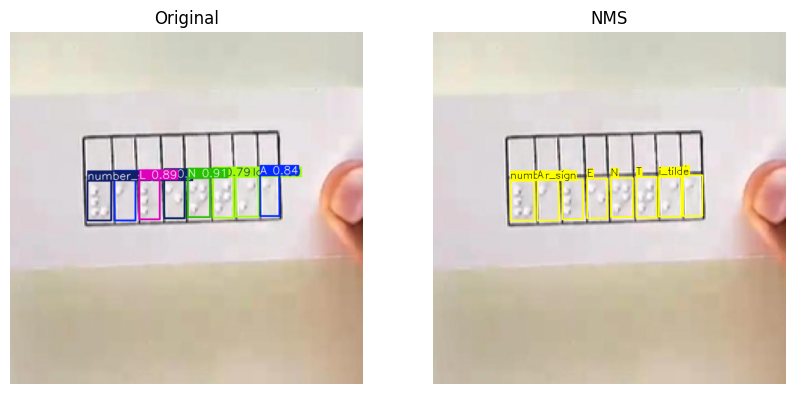

---------------------
1lentía
---------------------
['1lentía']
---------------------


In [ ]:
#@title prueba detección palabra supera wer RT-DETR
from ultralytics import RTDETR   # ← cambio clave
import os, cv2, matplotlib.pyplot as plt

# Cargar el modelo RT-DETR entrenado
model_trans = RTDETR('/content/drive/MyDrive/Trabajo de Grado/runs/detect/train_trans/weights/best.pt')

# Predicción sobre una imagen
print(os.getcwd())
results = model_trans.predict(
    source='/content/drive/MyDrive/Trabajo de Grado/Dataset - Yolo/valid/images/BRA444_png_jpg.rf.1499376c36ebbe0763425a84e2abfa78.jpg',
    save=False,
    conf=0.5
)

# Mostrar resultados en texto
for box in results[0].boxes:
    cls = int(box.cls[0])
    conf = float(box.conf[0])
    coords = box.xyxy[0].tolist()
    print(f"Clase: {results[0].names[cls]}, Confianza: {conf:.2f}, Coordenadas: {coords}")

# NMS + ordenamiento espacial
nms_results, text_results = nms_Yolo(results, results[0].orig_img, iou=0.3)
nms_results = cv2.cvtColor(nms_results, cv2.COLOR_BGR2RGB)
og_results = cv2.cvtColor(results[0].plot(), cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 10))
plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(og_results)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("NMS")
plt.imshow(nms_results)
plt.axis('off')

plt.show()

print("---------------------")
for line in text_results:
    print(line)
print("---------------------")
print(text_results)
print("---------------------")

In [24]:
#@title con los tres tts
from IPython.display import Audio, display
import pandas as pd
from ultralytics import YOLO
import cv2
import whisper
from jiwer import wer
import time
from gtts import gTTS
import os
import re
import subprocess
import tempfile
import unicodedata

# ==================== 0. TEXTO CORRECTO (GROUND TRUTH) ====================
print("="*60)
print(" PASO 0: Definir el texto CORRECTO (Ground Truth)")
print("="*60)

texto_ground_truth = "Valentía"

print(f" Texto correcto (Ground Truth): '{texto_ground_truth}'")
print("="*60)

# ==================== 1. DETECCIÓN CON rt-dert ====================
print("\n PASO 1: Detectando texto con rt-detr")
print("="*60)

model_trans = RTDETR('/content/drive/MyDrive/Trabajo de Grado/runs/detect/train_trans/weights/best.pt')

imagen_path = '/content/drive/MyDrive/Trabajo de Grado/Dataset - Yolo/valid/images/BRA444_png_jpg.rf.1499376c36ebbe0763425a84e2abfa78.jpg'

results = model_trans.predict(
    source=imagen_path,
    save=False,
    conf=0.5
)

nms_results, text_results = nms_Yolo(results, results[0].orig_img, iou=0.3)
texto_detectado_yolo = " ".join(text_results)

print(f" Texto detectado por YOLO: '{texto_detectado_yolo}'")
print("="*60)

# ==================== 2. LIMPIAR TEXTO ====================
def limpiar_texto_para_wer(texto):
    texto = texto.lower().strip()
    # 1. Quitar TODO lo que no sea letra/espacio (incluye ¡ ¿ « » … – — etc.)
    texto = re.sub(r'[^\w\s]', '', texto, flags=re.UNICODE)

    # 2. Proteger la ñ (y Ñ) antes de quitar tildes
    texto = texto.replace('ñ', '\x00')   # placeholder temporal

    # 3. Quitar tildes/diéresis (á→a, é→e, ü→u, etc.)
    texto = ''.join(
        c for c in unicodedata.normalize('NFD', texto)
        if unicodedata.category(c) != 'Mn'
    )

    # 4. Restaurar la ñ
    texto = texto.replace('\x00', 'ñ')

    # 5. Normalizar espacios
    texto = re.sub(r'\s+', ' ', texto)
    return texto.strip()

# ==================== 3. FUNCIONES TTS (CON TEMPORALES) ====================

# 3.1 gTTS
def tts_gtts(text):
    """Genera audio con gTTS en archivo temporal"""
    try:
        with tempfile.NamedTemporaryFile(suffix='.wav', delete=False) as tmp:
            tts = gTTS(text=text, lang='es', slow=False)
            tts.save(tmp.name)
            print(f"    gTTS: Audio generado temporalmente")
            return tmp.name
    except Exception as e:
        print(f"    gTTS: Error: {e}")
        return None

# 3.2 eSpeak
def tts_espeak(text):
    """Genera audio con eSpeak en archivo temporal"""
    try:
        with tempfile.NamedTemporaryFile(suffix='.wav', delete=False) as tmp:
            command = [
                'espeak-ng',
                '-v', 'es',
                '-s', str(130),
                '-w', tmp.name,
                text
            ]
            subprocess.run(command, check=True, capture_output=True, text=True)
            print(f"    eSpeak: Audio generado temporalmente")
            return tmp.name
    except subprocess.CalledProcessError as e:
        print(f"    eSpeak: Error: {e.stderr}")
        return None
    except FileNotFoundError:
        print("    eSpeak: 'espeak-ng' no encontrado. Instalar con: !apt-get install espeak-ng")
        return None

# 3.3 Festival
def tts_festival(text,lang = "es"):
    """Genera audio con Festival en archivo temporal"""
    try:
        # Seleccionar voz según idioma
        if lang == "es":
            voice = "(voice_el_diphone)"
        elif lang == "en":
            voice = "(voice_kal_diphone)"
        else:
            voice = "(voice_el_diphone)"  # fallback
        with tempfile.NamedTemporaryFile(suffix='.txt', delete=False) as txt_tmp:
            with open(txt_tmp.name, "w", encoding="latin-1") as f:
                f.write(text)

            with tempfile.NamedTemporaryFile(suffix='.wav', delete=False) as wav_tmp:
                command = [
                    'text2wave',
                    '-eval', voice,
                    '-o', wav_tmp.name,
                    txt_tmp.name
                ]

                subprocess.run(command, check=True, capture_output=True, text=True)
                os.remove(txt_tmp.name)  # Limpiar archivo temporal de texto
                print(f"    Festival: Audio generado temporalmente")
                return wav_tmp.name
    except subprocess.CalledProcessError as e:
        print(f"    Festival: Error: {e.stderr}")
        return None
    except FileNotFoundError:
        print("    Festival: 'text2wave' no encontrado. Instalar con: !apt-get install festival festival-dev festvox-es")
        return None
    except Exception as e:
        print(f"    Festival: Error inesperado: {e}")
        return None

# ==================== 4. TRANSCRIBIR CON WHISPER ====================
def transcribir_audio(audio_file, model_size="small"):
    try:
        model = whisper.load_model(model_size)
        result = model.transcribe(audio_file, language="es", fp16=False)
        return result["text"].strip()
    except Exception as e:
        print(f"    Error transcribiendo: {e}")
        return None

# ==================== 5. EVALUAR TTS ====================
def evaluar_tts(texto_referencia, audio_file, tts_name, whisper_model="small"):
    """
    Evalúa un TTS: transcribe el audio y calcula WER
    """
    print(f"\n Evaluando {tts_name}...")

    # REPRODUCIR AUDIO (en el aire)
    print(f"    Reproduciendo audio de {tts_name}...")
    display(Audio(audio_file, autoplay=True))

    # Transcribir con Whisper
    transcripcion = transcribir_audio(audio_file, whisper_model)

    if transcripcion is None:
        return None

    # Limpiar textos
    ref_clean = limpiar_texto_para_wer(texto_referencia)
    hyp_clean = limpiar_texto_para_wer(transcripcion)

    # Calcular WER
    wer_score = wer(ref_clean, hyp_clean)

    print(f"    Transcripción: '{transcripcion}'")
    print(f"    WER: {wer_score*100:.2f}%")

    # Limpiar archivo temporal después de usarlo
    try:
        os.remove(audio_file)
    except:
        pass

    return {
        'tts_name': tts_name,
        'transcripcion': transcripcion,
        'transcripcion_limpia': hyp_clean,
        'wer': wer_score,
        'wer_percent': wer_score * 100
    }

# ==================== 6. EJECUTAR EVALUACIÓN DE TODOS LOS TTS ====================
print("\n" + "="*60)
print(" PASO 2: Evaluando múltiples TTS")
print("="*60)

# Lista de TTS a evaluar
tts_models = [
    {'name': 'gTTS', 'func': tts_gtts},
    {'name': 'eSpeak', 'func': tts_espeak},
    {'name': 'Festival', 'func': tts_festival}
]

resultados = []

for tts in tts_models:
    print(f"\n{'='*50}")
    print(f" Probando {tts['name']}...")
    print("="*50)

    # Generar audio (archivo temporal)
    audio_file = tts['func'](texto_detectado_yolo)

    if audio_file is None:
        print(f"    {tts['name']} falló al generar audio. Saltando...")
        continue

    # Evaluar TTS (reproduce, transcribe, limpia archivo)
    resultado = evaluar_tts(texto_ground_truth, audio_file, tts['name'])

    if resultado:
        resultados.append(resultado)

    # Pequeña pausa entre TTS para no saturar
    time.sleep(1)

# ==================== 7. MOSTRAR COMPARATIVA ====================
print("\n" + "="*60)
print(" COMPARATIVA DE TTS")
print("="*60)

if not resultados:
    print(" No se pudo evaluar ningún TTS. Verifica las instalaciones.")
else:
    # Crear DataFrame
    df_comparativa = pd.DataFrame(resultados)

    # Ordenar por WER (mejor a peor)
    df_comparativa = df_comparativa.sort_values('wer')

    print("\n TABLA COMPARATIVA:")
    print("="*60)
    print(df_comparativa[['tts_name', 'wer_percent', 'transcripcion']].to_string(index=False))

    # Mostrar resumen
    print("\n" + "="*60)
    print(" RESULTADOS:")
    print("="*60)

    mejor = df_comparativa.iloc[0]
    print(f" MEJOR TTS: {mejor['tts_name']} (WER: {mejor['wer_percent']:.2f}%)")

    if len(df_comparativa) > 1:
        peor = df_comparativa.iloc[-1]
        print(f" PEOR TTS: {peor['tts_name']} (WER: {peor['wer_percent']:.2f}%)")

    # Mostrar comparación directa de transcripciones
    print("\n" + "="*60)
    print(" COMPARACIÓN DE TRANSCRIPCIONES:")
    print("="*60)
    print(f"\nGround Truth:    '{limpiar_texto_para_wer(texto_ground_truth)}'")

    for _, row in df_comparativa.iterrows():
        print(f"{row['tts_name']:12} '{row['transcripcion_limpia']}' (WER: {row['wer_percent']:.2f}%)")

print("\n" + "="*60)
print(" PROCESO COMPLETADO")
print("="*60)

 PASO 0: Definir el texto CORRECTO (Ground Truth)
 Texto correcto (Ground Truth): 'Valentía'

 PASO 1: Detectando texto con rt-detr

image 1/1 /content/drive/MyDrive/Trabajo de Grado/Dataset - Yolo/valid/images/BRA444_png_jpg.rf.1499376c36ebbe0763425a84e2abfa78.jpg: 640x640 2 As, 1 E, 1 I, 1 L, 1 N, 1 T, 1 i_tilde, 1 number_sign, 3277.0ms
Speed: 23.5ms preprocess, 3277.0ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 640)
 Texto detectado por YOLO: '1lentía'

 PASO 2: Evaluando múltiples TTS

 Probando gTTS...
    gTTS: Audio generado temporalmente

 Evaluando gTTS...
    Reproduciendo audio de gTTS...


    Transcripción: '1 lentía'
    WER: 200.00%

 Probando eSpeak...
    eSpeak: Audio generado temporalmente

 Evaluando eSpeak...
    Reproduciendo audio de eSpeak...


    Transcripción: '¡Uno de entidad!'
    WER: 300.00%

 Probando Festival...
    Festival: Audio generado temporalmente

 Evaluando Festival...
    Reproduciendo audio de Festival...


    Transcripción: 'Un LENTIA'
    WER: 200.00%

 COMPARATIVA DE TTS

 TABLA COMPARATIVA:
tts_name  wer_percent    transcripcion
    gTTS        200.0         1 lentía
Festival        200.0        Un LENTIA
  eSpeak        300.0 ¡Uno de entidad!

 RESULTADOS:
 MEJOR TTS: gTTS (WER: 200.00%)
 PEOR TTS: eSpeak (WER: 300.00%)

 COMPARACIÓN DE TRANSCRIPCIONES:

Ground Truth:    'valentia'
gTTS         '1 lentia' (WER: 200.00%)
Festival     'un lentia' (WER: 200.00%)
eSpeak       'uno de entidad' (WER: 300.00%)

 PROCESO COMPLETADO


#TTS SOLO CON GROUND TRUTH

In [12]:
#@title con los tres tts (SIN YOLO - solo ASR)
from IPython.display import Audio, display
import pandas as pd
import whisper
from jiwer import wer
import time
from gtts import gTTS
import os
import re
import subprocess
import tempfile
import unicodedata

# ==================== 0. TEXTO CORRECTO (GROUND TRUTH) ====================
print("="*60)
print(" PASO 0: Definir el texto CORRECTO (Ground Truth)")
print("="*60)

texto_ground_truth = "Bendita tu luz"

print(f"Texto correcto (Ground Truth): '{texto_ground_truth}'")
print("="*60)

# ==================== 1. LIMPIAR TEXTO ====================
def limpiar_texto_para_wer(texto):
    texto = texto.lower().strip()
    # 1. Quitar TODO lo que no sea letra/espacio (incluye ¡ ¿ « » … – — etc.)
    texto = re.sub(r'[^\w\s]', '', texto, flags=re.UNICODE)

    # 2. Proteger la ñ (y Ñ) antes de quitar tildes
    texto = texto.replace('ñ', '\x00')   # placeholder temporal

    # 3. Quitar tildes/diéresis (á→a, é→e, ü→u, etc.)
    texto = ''.join(
        c for c in unicodedata.normalize('NFD', texto)
        if unicodedata.category(c) != 'Mn'
    )

    # 4. Restaurar la ñ
    texto = texto.replace('\x00', 'ñ')

    # 5. Normalizar espacios
    texto = re.sub(r'\s+', ' ', texto)
    return texto.strip()

# ==================== 2. FUNCIONES TTS (CON TEMPORALES) ====================

# 2.1 gTTS
def tts_gtts(text):
    """Genera audio con gTTS en archivo temporal"""
    try:
        with tempfile.NamedTemporaryFile(suffix='.wav', delete=False) as tmp:
            tts = gTTS(text=text, lang='es', slow=False)
            tts.save(tmp.name)
            print(f"     gTTS: Audio generado temporalmente")
            return tmp.name
    except Exception as e:
        print(f"     gTTS: Error: {e}")
        return None

# 2.2 eSpeak
def tts_espeak(text):
    """Genera audio con eSpeak en archivo temporal"""
    try:
        with tempfile.NamedTemporaryFile(suffix='.wav', delete=False) as tmp:
            command = [
                'espeak-ng',
                '-v', 'es',
                '-s', str(130),
                '-w', tmp.name,
                text
            ]
            subprocess.run(command, check=True, capture_output=True, text=True)
            print(f"     eSpeak: Audio generado temporalmente")
            return tmp.name
    except subprocess.CalledProcessError as e:
        print(f"     eSpeak: Error: {e.stderr}")
        return None
    except FileNotFoundError:
        print("     eSpeak: 'espeak-ng' no encontrado. Instalar con: !apt-get install espeak-ng")
        return None

# 2.3 Festival
def tts_festival(text, lang="es"):
    """Genera audio con Festival en archivo temporal"""
    try:
        if lang == "es":
            voice = "(voice_el_diphone)"
        elif lang == "en":
            voice = "(voice_kal_diphone)"
        else:
            voice = "(voice_el_diphone)"

        with tempfile.NamedTemporaryFile(suffix='.txt', delete=False) as txt_tmp:
            with open(txt_tmp.name, "w", encoding="latin-1") as f:
                f.write(text)

            with tempfile.NamedTemporaryFile(suffix='.wav', delete=False) as wav_tmp:
                command = [
                    'text2wave',
                    '-eval', voice,
                    '-o', wav_tmp.name,
                    txt_tmp.name
                ]

                subprocess.run(command, check=True, capture_output=True, text=True)
                os.remove(txt_tmp.name)
                print(f"     Festival: Audio generado temporalmente")
                return wav_tmp.name
    except subprocess.CalledProcessError as e:
        print(f"     Festival: Error: {e.stderr}")
        return None
    except FileNotFoundError:
        print("     Festival: 'text2wave' no encontrado.")
        return None
    except Exception as e:
        print(f"     Festival: Error inesperado: {e}")
        return None

# ==================== 3. TRANSCRIBIR CON WHISPER ====================
def transcribir_audio(audio_file, model_size="small"):
    try:
        model = whisper.load_model(model_size)
        result = model.transcribe(audio_file, language="es", fp16=False)
        return result["text"].strip()
    except Exception as e:
        print(f"     Error transcribiendo: {e}")
        return None

# ==================== 4. EVALUAR TTS ====================
def evaluar_tts(texto_referencia, audio_file, tts_name, whisper_model="small"):
    """
    Evalúa un TTS: transcribe el audio y calcula WER
    """
    print(f"\n Evaluando {tts_name}...")

    # REPRODUCIR AUDIO
    print(f"     Reproduciendo audio de {tts_name}...")
    display(Audio(audio_file, autoplay=True))

    # Transcribir con Whisper
    transcripcion = transcribir_audio(audio_file, whisper_model)

    if transcripcion is None:
        return None

    # Limpiar textos
    ref_clean = limpiar_texto_para_wer(texto_referencia)
    hyp_clean = limpiar_texto_para_wer(transcripcion)

    # Calcular WER
    wer_score = wer(ref_clean, hyp_clean)

    print(f"     Transcripción: '{transcripcion}'")
    print(f"     WER: {wer_score*100:.2f}%")

    # Limpiar archivo temporal
    try:
        os.remove(audio_file)
    except:
        pass

    return {
        'tts_name': tts_name,
        'transcripcion': transcripcion,
        'transcripcion_limpia': hyp_clean,
        'wer': wer_score,
        'wer_percent': wer_score * 100
    }

# ==================== 5. EJECUTAR EVALUACIÓN DE TODOS LOS TTS ====================
print("\n" + "="*60)
print(" PASO 1: Evaluando múltiples TTS (SIN YOLO - solo ASR)")
print("="*60)

# Lista de TTS a evaluar
tts_models = [
    {'name': 'gTTS', 'func': tts_gtts},
    {'name': 'eSpeak', 'func': tts_espeak},
    {'name': 'Festival', 'func': tts_festival}
]

resultados = []

for tts in tts_models:
    print(f"\n{'='*50}")
    print(f" Probando {tts['name']}...")
    print("="*50)

    #  GENERAR AUDIO DIRECTO DESDE EL GROUND TRUTH (sin YOLO)
    audio_file = tts['func'](texto_ground_truth)

    if audio_file is None:
        print(f"     {tts['name']} falló al generar audio. Saltando...")
        continue

    # Evaluar TTS
    resultado = evaluar_tts(texto_ground_truth, audio_file, tts['name'])

    if resultado:
        resultados.append(resultado)

    time.sleep(1)

# ==================== 6. MOSTRAR COMPARATIVA ====================
print("\n" + "="*60)
print(" COMPARATIVA DE TTS (SIN YOLO)")
print("="*60)

if not resultados:
    print(" No se pudo evaluar ningún TTS. Verifica las instalaciones.")
else:
    df_comparativa = pd.DataFrame(resultados)
    df_comparativa = df_comparativa.sort_values('wer')

    print("\n TABLA COMPARATIVA:")
    print("="*60)
    print(df_comparativa[['tts_name', 'wer_percent', 'transcripcion']].to_string(index=False))

    # Resumen
    print("\n" + "="*60)
    print(" RESULTADOS:")
    print("="*60)

    mejor = df_comparativa.iloc[0]
    print(f" MEJOR TTS: {mejor['tts_name']} (WER: {mejor['wer_percent']:.2f}%)")

    if len(df_comparativa) > 1:
        peor = df_comparativa.iloc[-1]
        print(f" PEOR TTS: {peor['tts_name']} (WER: {peor['wer_percent']:.2f}%)")

    # Comparación directa
    print("\n" + "="*60)
    print(" COMPARACIÓN DE TRANSCRIPCIONES:")
    print("="*60)
    print(f"\nGround Truth:    '{limpiar_texto_para_wer(texto_ground_truth)}'")

    for _, row in df_comparativa.iterrows():
        print(f"{row['tts_name']:12} '{row['transcripcion_limpia']}' (WER: {row['wer_percent']:.2f}%)")

print("\n" + "="*60)
print(" PROCESO COMPLETADO")
print("="*60)

 PASO 0: Definir el texto CORRECTO (Ground Truth)
Texto correcto (Ground Truth): 'Bendita tu luz'

 PASO 1: Evaluando múltiples TTS (SIN YOLO - solo ASR)

 Probando gTTS...
     gTTS: Audio generado temporalmente

 Evaluando gTTS...
     Reproduciendo audio de gTTS...


     Transcripción: 'Bendita tu luz.'
     WER: 0.00%

 Probando eSpeak...
     eSpeak: Audio generado temporalmente

 Evaluando eSpeak...
     Reproduciendo audio de eSpeak...


     Transcripción: '¡Vendita tu luz!'
     WER: 33.33%

 Probando Festival...
     Festival: Audio generado temporalmente

 Evaluando Festival...
     Reproduciendo audio de Festival...


     Transcripción: '¡Ven vi paturlus!'
     WER: 100.00%

 COMPARATIVA DE TTS (SIN YOLO)

 TABLA COMPARATIVA:
tts_name  wer_percent     transcripcion
    gTTS     0.000000   Bendita tu luz.
  eSpeak    33.333333  ¡Vendita tu luz!
Festival   100.000000 ¡Ven vi paturlus!

 RESULTADOS:
 MEJOR TTS: gTTS (WER: 0.00%)
 PEOR TTS: Festival (WER: 100.00%)

 COMPARACIÓN DE TRANSCRIPCIONES:

Ground Truth:    'bendita tu luz'
gTTS         'bendita tu luz' (WER: 0.00%)
eSpeak       'vendita tu luz' (WER: 33.33%)
Festival     'ven vi paturlus' (WER: 100.00%)

 PROCESO COMPLETADO


In [3]:
#@title promedio y comparación de 3 textos SOLO ASR
from IPython.display import Audio, display
import pandas as pd
import whisper
from jiwer import wer
import time
from gtts import gTTS
import os
import re
import subprocess
import tempfile
import unicodedata

# ==================== 0. GROUND TRUTH PARA CADA TEXTO ====================
print("="*60)
print(" PASO 0: Definir los textos CORRECTOS (Ground Truth)")
print("="*60)

#  Lista de textos con su ground truth (SIN imágenes, SIN YOLO)
textos = [
    {
        'nombre': 'Texto 1',
        'ground_truth': 'valentía'
    },
    {
        'nombre': 'Texto 2',
        'ground_truth': 'Bendita tu luz'
    },
    {
        'nombre': 'Texto 3',
        'ground_truth': 'cambio todo en mí'
    }
]

print(f" {len(textos)} textos configurados")
for txt in textos:
    print(f"   - {txt['nombre']}: '{txt['ground_truth']}'")
print("="*60)

# ==================== 1. FUNCIÓN DE LIMPIEZA ====================
def limpiar_texto_para_wer(texto):
    texto = texto.lower().strip()
    # 1. Quitar TODO lo que no sea letra/espacio
    texto = re.sub(r'[^\w\s]', '', texto, flags=re.UNICODE)

    # 2. Proteger la ñ
    texto = texto.replace('ñ', '\x00')

    # 3. Quitar tildes/diéresis
    texto = ''.join(
        c for c in unicodedata.normalize('NFD', texto)
        if unicodedata.category(c) != 'Mn'
    )

    # 4. Restaurar la ñ
    texto = texto.replace('\x00', 'ñ')

    # 5. Normalizar espacios
    texto = re.sub(r'\s+', ' ', texto)
    return texto.strip()

# ==================== 2. FUNCIONES TTS ====================

# 2.1 gTTS
def tts_gtts(text):
    try:
        with tempfile.NamedTemporaryFile(suffix='.wav', delete=False) as tmp:
            tts = gTTS(text=text, lang='es', slow=False)
            tts.save(tmp.name)
            return tmp.name
    except Exception as e:
        print(f"     gTTS Error: {e}")
        return None

# 2.2 eSpeak
def tts_espeak(text):
    try:
        with tempfile.NamedTemporaryFile(suffix='.wav', delete=False) as tmp:
            command = ['espeak-ng', '-v', 'es', '-w', tmp.name, text]
            subprocess.run(command, check=True, capture_output=True, text=True)
            return tmp.name
    except:
        return None

# 2.3 Festival
def tts_festival(text, lang="es"):
    try:
        if lang == "es":
            voice = "(voice_el_diphone)"
        elif lang == "en":
            voice = "(voice_kal_diphone)"
        else:
            voice = "(voice_el_diphone)"

        with tempfile.NamedTemporaryFile(suffix='.txt', delete=False) as txt_tmp:
            with open(txt_tmp.name, "w", encoding="latin-1") as f:
                f.write(text)

            with tempfile.NamedTemporaryFile(suffix='.wav', delete=False) as wav_tmp:
                command = [
                    'text2wave',
                    '-eval', voice,
                    '-o', wav_tmp.name,
                    txt_tmp.name
                ]
                subprocess.run(command, check=True, capture_output=True, text=True)
                os.remove(txt_tmp.name)
                return wav_tmp.name
    except subprocess.CalledProcessError as e:
        print(f"     Festival: Error: {e.stderr}")
        return None
    except FileNotFoundError:
        print("     Festival: 'text2wave' no encontrado.")
        return None
    except Exception as e:
        print(f"     Festival: Error inesperado: {e}")
        return None

# ==================== 3. TRANSCRIBIR CON WHISPER ====================
def transcribir_audio(audio_file, model_size="small"):
    try:
        model = whisper.load_model(model_size)
        result = model.transcribe(audio_file, language="es", fp16=False)
        return result["text"].strip()
    except Exception as e:
        print(f"     Error transcribiendo: {e}")
        return None

# ==================== 4. EVALUAR TTS PARA UN TEXTO ====================
def evaluar_tts_texto(texto_ground_truth, tts_name, tts_func):
    """
    Evalúa un TTS para un texto específico (SIN YOLO)
    """
    #  Generar audio DIRECTO desde el ground truth
    audio_file = tts_func(texto_ground_truth)

    if audio_file is None:
        return None

    # Transcribir con Whisper
    transcripcion = transcribir_audio(audio_file)

    if transcripcion is None:
        try:
            os.remove(audio_file)
        except:
            pass
        return None

    # Limpiar textos
    ref_clean = limpiar_texto_para_wer(texto_ground_truth)
    hyp_clean = limpiar_texto_para_wer(transcripcion)

    # Calcular WER
    wer_score = wer(ref_clean, hyp_clean)

    # Limpiar archivo temporal
    try:
        os.remove(audio_file)
    except:
        pass

    return {
        'tts_name': tts_name,
        'transcripcion': transcripcion,
        'wer': wer_score,
        'wer_percent': wer_score * 100
    }

# ==================== 5. PROCESAR TEXTOS ====================
print("\n" + "="*60)
print(" PROCESANDO TEXTOS (SIN YOLO - solo ASR)")
print("="*60)

# Lista de TTS
tts_models = [
    {'name': 'gTTS', 'func': tts_gtts},
    {'name': 'eSpeak', 'func': tts_espeak},
    {'name': 'Festival', 'func': tts_festival}
]

# Almacenar todos los resultados
todos_resultados = []

for txt in textos:
    print(f"\n{'='*60}")
    print(f" Procesando: {txt['nombre']}")
    print(f"   Ground Truth: '{txt['ground_truth']}'")
    print("="*60)

    # Evaluar cada TTS para este texto
    for tts in tts_models:
        resultado = evaluar_tts_texto(
            txt['ground_truth'],
            tts['name'],
            tts['func']
        )

        if resultado:
            resultado['texto_nombre'] = txt['nombre']
            resultado['ground_truth'] = txt['ground_truth']
            todos_resultados.append(resultado)
            print(f"      {tts['name']:10} → WER: {resultado['wer_percent']:.2f}% | '{resultado['transcripcion']}'")
        else:
            print(f"      {tts['name']:10} →  Falló")

# ==================== 6. CALCULAR ESTADÍSTICAS ====================
print("\n" + "="*60)
print(" ESTADÍSTICAS POR TTS")
print("="*60)

if not todos_resultados:
    print(" No se obtuvieron resultados")
else:
    # Crear DataFrame
    df = pd.DataFrame(todos_resultados)

    # Calcular promedio por TTS
    promedio_wer = df.groupby('tts_name')['wer'].mean().reset_index()
    promedio_wer.columns = ['tts_name', 'wer_promedio']
    promedio_wer['wer_promedio_percent'] = promedio_wer['wer_promedio'] * 100
    promedio_wer = promedio_wer.sort_values('wer_promedio')

    print("\n PROMEDIO WER POR TTS:")
    print("="*60)
    print(promedio_wer[['tts_name', 'wer_promedio_percent']].to_string(index=False))



    # 📊 Tabla detallada por texto
    print("\n📊 TABLA DETALLADA (por texto):")
    print("="*60)

    tabla_detalle = df.pivot_table(
        index='texto_nombre',
        columns='tts_name',
        values='wer_percent',
        aggfunc='first'
    ).reset_index()

    # Añadir ground truth para referencia
    gt_map = {t['nombre']: t['ground_truth'] for t in textos}
    tabla_detalle.insert(1, 'ground_truth', tabla_detalle['texto_nombre'].map(gt_map))

    print(tabla_detalle.to_string(index=False))

    # ==================== TABLA RESUMEN FINAL ====================
    print("\n" + "="*60)
    print(" TABLA RESUMEN FINAL (Promedio de los 3 textos)")
    print("="*60)

    # Calcular estadísticas completas por TTS
    resumen_final = df.groupby('tts_name').agg(
        WER_Promedio=('wer_percent', 'mean'),
        WER_Minimo=('wer_percent', 'min'),
        WER_Maximo=('wer_percent', 'max'),
        Textos_Probados=('wer_percent', 'count')
    ).reset_index()

    # Ordenar por WER promedio (mejor a peor)
    resumen_final = resumen_final.sort_values('WER_Promedio').reset_index(drop=True)

    # Añadir ranking y emoji
    medallas = ['🥇', '🥈', '🥉']
    resumen_final.insert(0, 'Ranking', [medallas[i] if i < len(medallas) else f'{i+1}°'
                                        for i in range(len(resumen_final))])

    # Formatear columnas
    resumen_final['WER_Promedio'] = resumen_final['WER_Promedio'].round(2)
    resumen_final['WER_Minimo'] = resumen_final['WER_Minimo'].round(2)
    resumen_final['WER_Maximo'] = resumen_final['WER_Maximo'].round(2)

    # Renombrar para mejor visualización
    resumen_final.columns = [
        'Ranking', 'TTS', 'WER Promedio (%)', 'WER Mínimo (%)',
        'WER Máximo (%)', 'Textos Probados'
    ]

    print(resumen_final.to_string(index=False))

    # ==================== VISUALIZACIÓN DE BARRAS ====================
    print("\n" + "="*60)
    print(" GRÁFICO DE BARRAS (WER Promedio)")
    print("="*60)

    for _, row in resumen_final.iterrows():
        tts_name = row['TTS']
        wer_val = row['WER Promedio (%)']
        ranking = row['Ranking']

        # Crear barra visual (cada █ = 2%)
        barra = '█' * int(wer_val / 2)
        if barra == '':
            barra = '▏'  # Mínimo visible

        print(f"   {ranking} {tts_name:10} |{barra:<30}| {wer_val:.2f}%")


    # ==================== 7. COMPARACIÓN DE TRANSCRIPCIONES ====================
    print("\n" + "="*60)
    print(" COMPARACIÓN DE TRANSCRIPCIONES:")
    print("="*60)

    for txt in textos:
        print(f"\n {txt['nombre']}: '{txt['ground_truth']}'")
        for _, row in df[df['texto_nombre'] == txt['nombre']].iterrows():
            print(f"   {row['tts_name']:10} '{row['transcripcion']}' (WER: {row['wer_percent']:.2f}%)")

print("\n" + "="*60)
print(" PROCESO COMPLETADO")
print("="*60)

 PASO 0: Definir los textos CORRECTOS (Ground Truth)
 3 textos configurados
   - Texto 1: 'valentía'
   - Texto 2: 'Bendita tu luz'
   - Texto 3: 'cambio todo en mí'

 PROCESANDO TEXTOS (SIN YOLO - solo ASR)

 Procesando: Texto 1
   Ground Truth: 'valentía'
      gTTS       → WER: 0.00% | '¡Valentía!'
      eSpeak     → WER: 100.00% | 'Argentina.'
      Festival   → WER: 0.00% | '¡Valentía!'

 Procesando: Texto 2
   Ground Truth: 'Bendita tu luz'
      gTTS       → WER: 0.00% | 'Bendita tu luz.'
      eSpeak     → WER: 33.33% | '¡Bendita, tú ruf!'
      Festival   → WER: 100.00% | '¡Ven vi paturlus!'

 Procesando: Texto 3
   Ground Truth: 'cambio todo en mí'
      gTTS       → WER: 0.00% | 'Cambió todo en mí.'
      eSpeak     → WER: 0.00% | 'Cambio todo en mi.'
      Festival   → WER: 0.00% | 'Cambio todo en mi'

 ESTADÍSTICAS POR TTS

 PROMEDIO WER POR TTS:
tts_name  wer_promedio_percent
    gTTS              0.000000
Festival             33.333333
  eSpeak             44.444444

📊 T